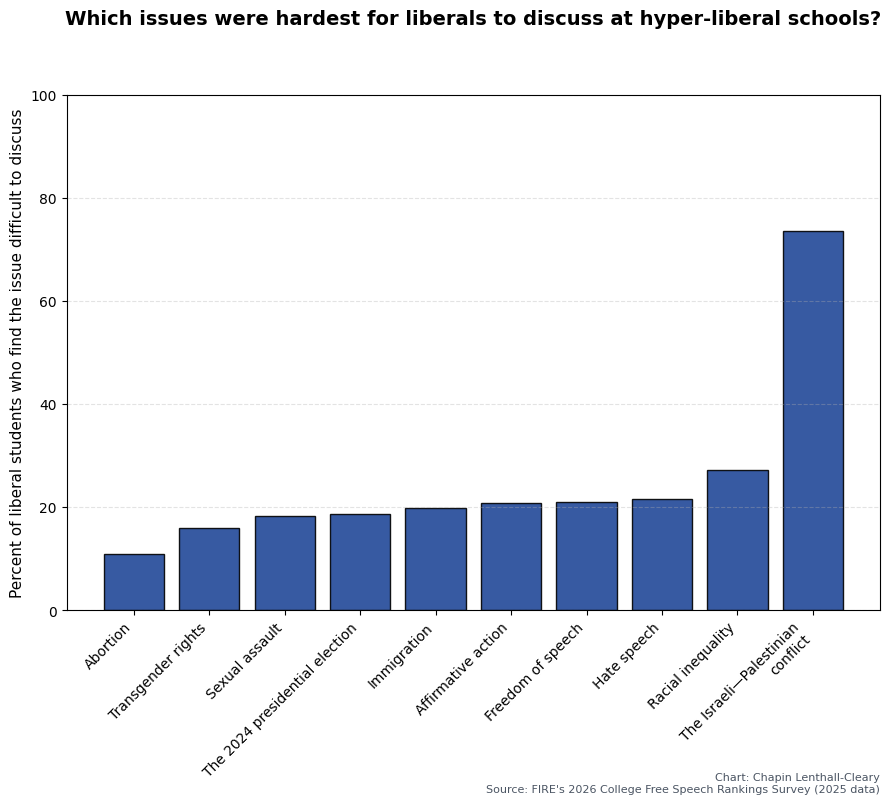

     question                       issue_label  pct_yes  n_valid
  tk_abortion                          Abortion     10.9     1493
     tk_trans                Transgender rights     16.0     1493
  tk_sexasslt                    Sexual assault     18.3     1493
  tk_preselec    The 2024 presidential election     18.7     1493
     tk_immig                       Immigration     19.8     1493
 tk_affirmact                Affirmative action     20.8     1493
tk_freespeech                 Freedom of speech     21.0     1493
tk_hatespeech                       Hate speech     21.6     1493
  tk_raceineq                 Racial inequality     27.1     1493
       tk_ipc The Israeli—Palestinian\nconflict     73.5     1493


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.colors import LinearSegmentedColormap

# --- Settings ---
INPUT_CSV    = "cfsrALL.csv"
SCHOOL_COL   = "schoolname"
IDEO_COL     = "ideo"
DATAYEAR_COL = "datayear"

TARGET_YEAR  = 2025
TARGET_BIN_LABEL = "2.0 to 2.5"   # actual bin in this coding; more liberal schools

# Hand-picked "spicy" issues for this plot
SPICY_TK_COLS = [
    "tk_ipc",         # Israeli/Palestinian conflict
    "tk_trans",       # Transgender rights
    "tk_abortion",    # Abortion
    "tk_hatespeech",  # Hate speech
    "tk_freespeech",  # Freedom of speech
    "tk_preselec",    # 2024 presidential election
    "tk_raceineq",    # Racial inequality
    "tk_affirmact",   # Affirmative action
    "tk_immig",       # Immigration
    "tk_sexasslt",    # Sexual assault
]

# Liberal group for this plot
LIBERAL_CODES = [1, 2, 3, 8]   # very/somewhat/slightly liberal + Democratic Socialist

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Binning
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0

# Credits / layout
CREDITS_COLOR = "#4b5563"
SUPTITLE_Y_TOP = 0.972
SUPTITLE_Y_BOTTOM = 0.943
CREDITS_Y = 0.1
TIGHT_RECT = [0.08, 0.10, 0.98, 0.90]

# Color mapping for bins (blue -> purple -> red)
CMAP_LR = LinearSegmentedColormap.from_list(
    "blue_purple_red",
    ["#084594", "#6a51a3", "#b10026"],
)

# Full issue labels
ISSUE_LABELS = {
    "tk_abortion": "Abortion",
    "tk_affirmact": "Affirmative action",
    "tk_feminism": "Feminism",
    "tk_gunctrl": "Gun control",
    "tk_immig": "Immigration",
    "tk_ipc": "The Israeli—Palestinian conflict",
    "tk_raceineq": "Racial inequality",
    "tk_trans": "Transgender rights",
    "tk_sexasslt": "Sexual assault",
    "tk_socmeddplt": "Social media deplatforming",
    "tk_none": "None of the above",
    "tk_china": "China",
    "tk_climate": "Climate change",
    "tk_covid19": "Coronavirus",
    "tk_econineq": "Economic inequality",
    "tk_genderineq": "Gender inequality",
    "tk_floyd": "George Floyd protests",
    "tk_maskmndt": "Mask mandates",
    "tk_police": "Police misconduct",
    "tk_vaxmndt": "COVID-19 vaccine mandates",
    "tk_freespeech": "Freedom of speech",
    "tk_inflation": "Inflation",
    "tk_scotus": "The Supreme Court",
    "tk_ukraine": "War in Ukraine",
    "tk_crime": "Crime",
    "tk_gayrights": "Gay rights",
    "tk_hatespeech": "Hate speech",
    "tk_preselec": "The 2024 presidential election",
    "tk_religion": "Religion",
}


def leaning_val_to_color(score):
    if pd.isna(score):
        return "#9ca3af"
    t = (3.0 - score) / 6.0
    t = max(0.0, min(1.0, t))
    return CMAP_LR(t)


def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def issue_label_from_col(col, wrap_width=30):
    label = ISSUE_LABELS.get(col, col)
    return textwrap.fill(label, width=wrap_width, break_long_words=False)


def format_display_range_from_actual(actual_low, actual_high):
    vals = sorted([-actual_low, -actual_high])
    return f"{vals[0]:.1f} to {vals[1]:.1f}"


def place_suptitle_over_axes(fig, ax, top_line, bottom_line):
    bbox = ax.get_position()
    x_center = float((bbox.x0 + bbox.x1) / 2.0)

    fig.text(
        x_center, SUPTITLE_Y_TOP, top_line,
        ha="center", va="top",
        fontsize=14, fontweight="bold"
    )
    fig.text(
        x_center, SUPTITLE_Y_BOTTOM, bottom_line,
        ha="center", va="top",
        fontsize=12, fontweight="normal"
    )


def add_credits_aligned_to_axes(fig, ax, year):
    bbox = ax.get_position()
    x_right = float(bbox.x1)

    survey_year_label = 2024 if int(year) == 2023 else 2026
    credits_text = (
        "Chart: Chapin Lenthall-Cleary\n"
        f"Source: FIRE's {survey_year_label} College Free Speech Rankings Survey ({year} data)"
    )

    fig.text(
        x_right, CREDITS_Y, credits_text,
        ha="right", va="bottom",
        fontsize=8, color=CREDITS_COLOR
    )


def compute_school_leaning_scores(df):
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1-9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)
    grp = df_valid.groupby(SCHOOL_COL, dropna=True)

    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")
    return leaning_score.reset_index()


def build_selected_spicy_questions(df_bin):
    """
    For respondents in the target leaning bin, combine all genders and compute
    percent 'yes' for liberals only on the chosen spicy issue set.
    """
    rows = []
    for col in SPICY_TK_COLS:
        if col not in df_bin.columns:
            continue

        valid_mask = df_bin[col].isin([0, 1]) & df_bin[IDEO_COL].isin(LIBERAL_CODES)
        n_valid = int(valid_mask.sum())
        if n_valid == 0:
            continue

        n_yes = int((df_bin.loc[valid_mask, col] == 1).sum())
        pct_yes = 100.0 * n_yes / n_valid

        rows.append({
            "question": col,
            "issue_label": issue_label_from_col(col),
            "n_valid": n_valid,
            "n_yes": n_yes,
            "pct_yes": pct_yes,
        })

    if not rows:
        raise ValueError("None of the selected spicy issues have valid liberal 0/1 responses in the target bin.")

    out = pd.DataFrame(rows)
    out = out.sort_values(["pct_yes", "n_valid", "issue_label"], ascending=[False, False, True])
    out = out.sort_values("pct_yes", ascending=True).reset_index(drop=True)
    return out


def make_spicy_bar_graph(df_all, year=TARGET_YEAR):
    df = df_all.copy()
    df.columns = [c.strip() for c in df.columns]

    _require_cols(df, [SCHOOL_COL, IDEO_COL, DATAYEAR_COL] + SPICY_TK_COLS)

    df[DATAYEAR_COL] = pd.to_numeric(df[DATAYEAR_COL], errors="coerce")
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")

    df = df[df[DATAYEAR_COL] == year].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {year}.")

    leanings = compute_school_leaning_scores(df)

    df_lean = df.merge(leanings, on=SCHOOL_COL, how="left")
    df_lean = df_lean[df_lean["leaning_score"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No respondents with a computed leaning_score after merging.")

    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}" for i in range(len(bin_edges) - 1)]

    df_lean["leaning_bin"] = pd.cut(
        df_lean["leaning_score"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
        right=True,
    )
    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No rows fall into the defined leaning bins.")

    df_target = df_lean[df_lean["leaning_bin"] == TARGET_BIN_LABEL].copy()
    if df_target.empty:
        raise ValueError(f"No rows found in bin {TARGET_BIN_LABEL} ({year}).")

    spicy = build_selected_spicy_questions(df_target)

    bar_color = leaning_val_to_color(2.25)
    fig_height = max(6.5, 0.60 * len(spicy) + 3.0)
    fig, ax = plt.subplots(figsize=(10, fig_height))

    bars = ax.bar(
        spicy["issue_label"],
        spicy["pct_yes"],
        color=bar_color,
        edgecolor="black",
        alpha=0.9,
    )

    ax.set_ylim(0, 100)
    ax.set_ylabel("Percent of liberal students who find the issue difficult to discuss", fontsize=11)
    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.tick_params(axis="x", labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

    fig.tight_layout(rect=TIGHT_RECT)
    place_suptitle_over_axes(
        fig,
        ax,
        "Which issues were hardest for liberals to discuss at hyper-liberal schools?",
        ""
    )
    add_credits_aligned_to_axes(fig, ax, year)

    plt.show()
    plt.close(fig)

    return spicy


# --- Run ---
df_all = pd.read_csv(INPUT_CSV, low_memory=False)
selected_df = make_spicy_bar_graph(df_all, year=TARGET_YEAR)
print(selected_df[["question", "issue_label", "pct_yes", "n_valid"]].to_string(index=False, float_format=lambda x: f"{x:.1f}"))

In [2]:
# If you're in a Jupyter notebook/lab, this creates a Year dropdown widget
# that re-runs and displays ONLY:
#   1) the 2.0 to 2.5 leaning-bin plot
#   2) the combined -0.5 to 0.5 plot
#
# Exclusions applied:
# - Exclude column exactly named: tk_none
# - Exclude any columns starting with: tkpol*  (case-insensitive)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from matplotlib.colors import LinearSegmentedColormap

# Widget bits (Jupyter)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False


# --- Settings ---
INPUT_CSV    = "cfsrALL.csv"
SCHOOL_COL   = "schoolname"
IDEO_COL     = "ideo"
GENDER_COL   = "gender_bin"    # 1 = Male, 2 = Female
DATAYEAR_COL = "datayear"

# Target plots
TARGET_BIN_LABEL = "2.0 to 2.5"   # in this script, positive = more liberal school
COMBINED_LOW = -0.5
COMBINED_HIGH = 0.5
COMBINED_LABEL = f"{COMBINED_LOW:.1f} to {COMBINED_HIGH:.1f} (combined)"

# Credits / layout
CREDITS_COLOR = "#4b5563"
SUPTITLE_Y_TOP = 0.972
SUPTITLE_Y_BOTTOM = 0.943
CREDITS_Y = 0.035
TIGHT_RECT = [0.06, 0.08, 0.98, 0.90]

# Ideology groupings for scatter axes
LIBERAL_CODES = [1, 2, 3, 8]
CONSERVATIVE_CODES = [5, 6, 7]

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Binning
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0

# Color mapping for bins (blue -> purple -> red)
CMAP_LR = LinearSegmentedColormap.from_list(
    "blue_purple_red",
    ["#084594", "#6a51a3", "#b10026"],
)

# Full issue labels
ISSUE_LABELS = {
    "tk_abortion": "Abortion",
    "tk_affirmact": "Affirmative action",
    "tk_feminism": "Feminism",
    "tk_gunctrl": "Gun control",
    "tk_immig": "Immigration",
    "tk_ipc": "The Israeli/Palestinian conflict",
    "tk_raceineq": "Racial inequality",
    "tk_trans": "Transgender rights",
    "tk_sexasslt": "Sexual assault",
    "tk_socmeddplt": "Social media deplatforming",
    "tk_none": "None of the above",
    "tk_china": "China",
    "tk_climate": "Climate change",
    "tk_covid19": "Coronavirus",
    "tk_econineq": "Economic inequality",
    "tk_genderineq": "Gender inequality",
    "tk_floyd": "George Floyd protests",
    "tk_maskmndt": "Mask mandates",
    "tk_police": "Police misconduct",
    "tk_vaxmndt": "COVID-19 vaccine mandates",
    "tk_freespeech": "Freedom of speech",
    "tk_inflation": "Inflation",
    "tk_scotus": "The Supreme Court",
    "tk_ukraine": "War in Ukraine",
    "tk_crime": "Crime",
    "tk_gayrights": "Gay rights",
    "tk_hatespeech": "Hate speech",
    "tk_preselec": "The 2024 presidential election",
    "tk_religion": "Religion",
}


def leaning_val_to_color(score):
    if pd.isna(score):
        return "#9ca3af"
    t = (3.0 - score) / 6.0
    t = max(0.0, min(1.0, t))
    return CMAP_LR(t)


def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def _get_tk_cols_excluding(df_cols):
    tk_cols = []
    for col in df_cols:
        c = col.lower()
        if not c.startswith("tk"):
            continue
        if c == "tk_none":
            continue
        if c.startswith("tkpol"):
            continue
        tk_cols.append(col)
    return tk_cols


def format_display_range_from_actual(actual_low, actual_high):
    vals = sorted([-actual_low, -actual_high])
    return f"{vals[0]:.1f} to {vals[1]:.1f}"


def issue_label_from_col(col, wrap_width=16):
    label = ISSUE_LABELS.get(col, col)
    return textwrap.fill(label, width=wrap_width, break_long_words=False)


def place_suptitle_over_axes(fig, axes, top_line, bottom_line):
    axes = np.ravel(axes)
    bboxes = [ax.get_position() for ax in axes]
    x0 = min(b.x0 for b in bboxes)
    x1 = max(b.x1 for b in bboxes)
    x_center = (x0 + x1) / 2.0

    fig.text(
        x_center, SUPTITLE_Y_TOP, top_line,
        ha="center", va="top",
        fontsize=14, fontweight="bold"
    )
    fig.text(
        x_center, SUPTITLE_Y_BOTTOM, bottom_line,
        ha="center", va="top",
        fontsize=12, fontweight="normal"
    )


def add_credits_aligned_to_axes(fig, axes, year):
    axes = np.ravel(axes)
    bboxes = [ax.get_position() for ax in axes]
    x_right = max(b.x1 for b in bboxes)

    survey_year_label = 2024 if int(year) == 2023 else 2026

    credits_text = (
        "Chart: Chapin Lenthall-Cleary\n"
        f"Source: FIRE's {survey_year_label} College Free Speech Rankings Survey ({year} data)"
    )

    fig.text(
        x_right, CREDITS_Y, credits_text,
        ha="right", va="bottom",
        fontsize=8, color=CREDITS_COLOR
    )


def _build_scatter_rows(df_bg, tk_cols_full):
    rows = []

    for col in tk_cols_full:
        lib_valid_mask = df_bg[col].isin([0, 1]) & df_bg[IDEO_COL].isin(LIBERAL_CODES)
        lib_n = int(lib_valid_mask.sum())
        if lib_n == 0:
            continue
        lib_yes = int((df_bg.loc[lib_valid_mask, col] == 1).sum())
        pct_yes_lib = 100.0 * lib_yes / lib_n

        con_valid_mask = df_bg[col].isin([0, 1]) & df_bg[IDEO_COL].isin(CONSERVATIVE_CODES)
        con_n = int(con_valid_mask.sum())
        if con_n == 0:
            continue
        con_yes = int((df_bg.loc[con_valid_mask, col] == 1).sum())
        pct_yes_con = 100.0 * con_yes / con_n

        rows.append(
            dict(
                question=col,
                pct_yes_liberal_any=pct_yes_lib,
                pct_yes_conservative_any=pct_yes_con,
                n_liberal_valid=lib_n,
                n_conservative_valid=con_n,
            )
        )

    return rows


def _rects_overlap(a, b, pad=0.0):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    return not (
        ax1 + pad < bx0 or
        bx1 + pad < ax0 or
        ay1 + pad < by0 or
        by1 + pad < ay0
    )


def add_sensible_issue_labels(
    ax,
    scatter_df,
    x_col="pct_yes_liberal_any",
    y_col="pct_yes_conservative_any",
    label_col="issue_label",
    fontsize=8,
):
    """
    Greedy label placement in display coordinates.
    Tries many nearby candidate positions, keeps labels inside the axes,
    and avoids overlap much better than the earlier version.
    """
    if scatter_df.empty:
        return

    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    ax_bbox = ax.get_window_extent(renderer=renderer)

    def _text_box_px(label):
        temp = fig.text(0, 0, label, fontsize=fontsize, ha="left", va="bottom")
        bb = temp.get_window_extent(renderer=renderer).expanded(1.08, 1.16)
        temp.remove()
        return bb.width, bb.height

    def _bbox_from_anchor(anchor_x, anchor_y, w, h, ha, va):
        if ha == "left":
            x0, x1 = anchor_x, anchor_x + w
        elif ha == "right":
            x0, x1 = anchor_x - w, anchor_x
        else:
            x0, x1 = anchor_x - w / 2.0, anchor_x + w / 2.0

        if va == "bottom":
            y0, y1 = anchor_y, anchor_y + h
        elif va == "top":
            y0, y1 = anchor_y - h, anchor_y
        else:
            y0, y1 = anchor_y - h / 2.0, anchor_y + h / 2.0

        return (x0, y0, x1, y1)

    def _overflow_amount(box):
        x0, y0, x1, y1 = box
        overflow = 0.0
        overflow += max(0.0, ax_bbox.x0 - x0)
        overflow += max(0.0, x1 - ax_bbox.x1)
        overflow += max(0.0, ax_bbox.y0 - y0)
        overflow += max(0.0, y1 - ax_bbox.y1)
        return overflow

    pts_data = scatter_df[[x_col, y_col]].to_numpy(dtype=float)
    pts_disp = ax.transData.transform(pts_data)

    # Place the most crowded points first
    n = len(scatter_df)
    nearest = np.full(n, np.inf)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            d = np.hypot(pts_disp[i, 0] - pts_disp[j, 0], pts_disp[i, 1] - pts_disp[j, 1])
            if d < nearest[i]:
                nearest[i] = d

    order = np.argsort(nearest)
    work = scatter_df.iloc[order].reset_index(drop=True)
    pts_disp_ordered = pts_disp[order]

    dpi_scale = fig.dpi / 72.0

    # Candidate offsets in points: small to larger, diagonal first, then sides
    candidate_specs = []
    for r in (8, 12, 16, 20, 26, 32):
        candidate_specs.extend([
            ( r,  r, "left",   "bottom"),
            ( r, -r, "left",   "top"),
            (-r,  r, "right",  "bottom"),
            (-r, -r, "right",  "top"),
            ( r,  0, "left",   "center"),
            (-r,  0, "right",  "center"),
            ( 0,  r, "center", "bottom"),
            ( 0, -r, "center", "top"),
        ])

    placed_boxes = []

    for idx, (_, row) in enumerate(work.iterrows()):
        px, py = pts_disp_ordered[idx]
        label = str(row[label_col])
        w, h = _text_box_px(label)

        best = None
        best_score = None

        for dx_pt, dy_pt, ha, va in candidate_specs:
            ax_x = px + dx_pt * dpi_scale
            ax_y = py + dy_pt * dpi_scale
            box = _bbox_from_anchor(ax_x, ax_y, w, h, ha, va)

            overlaps = sum(_rects_overlap(box, prev, pad=3.0) for prev in placed_boxes)
            overflow = _overflow_amount(box)
            dist_penalty = abs(dx_pt) + abs(dy_pt)

            # Strongly prefer no overlap, then staying in-bounds, then shorter leader lines
            score = overlaps * 1_000_000 + overflow * 10_000 + dist_penalty

            if best_score is None or score < best_score:
                best_score = score
                best = (dx_pt, dy_pt, ha, va, box)

            if overlaps == 0 and overflow == 0:
                break

        dx_pt, dy_pt, ha, va, box = best
        placed_boxes.append(box)

        ax.annotate(
            label,
            xy=(float(row[x_col]), float(row[y_col])),
            xytext=(dx_pt, dy_pt),
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=fontsize,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.82, pad=0.25),
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.6, shrinkA=0, shrinkB=3),
            annotation_clip=True,
            zorder=5,
        )


def _render_two_panel_plot(
    df_plot,
    year,
    plot_label,
    school_type_label,
    actual_low,
    actual_high,
    plot_color,
    tk_cols_full,
):
    gender_info = {1: "Men", 2: "Women"}
    gender_codes = [1, 2]
    display_range = format_display_range_from_actual(actual_low, actual_high)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharex=True, sharey=True)

    for idx, g_code in enumerate(gender_codes):
        ax = axes[idx]
        g_label = gender_info[g_code]

        df_bg = df_plot[df_plot[GENDER_COL] == g_code]
        rows = _build_scatter_rows(df_bg, tk_cols_full)

        if not rows:
            ax.text(50, 50, "No valid data", ha="center", va="center", fontsize=11)
            ax.set_title(g_label)
            ax.set_xlim(0, 100)
            ax.set_ylim(0, 100)
            ax.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1)
            continue

        scatter_df = pd.DataFrame(rows)
        scatter_df["issue_label"] = scatter_df["question"].map(issue_label_from_col)

        ax.scatter(
            scatter_df["pct_yes_liberal_any"],
            scatter_df["pct_yes_conservative_any"],
            c=[plot_color] * len(scatter_df),
            edgecolors="black",
            s=50,
            alpha=0.85,
            zorder=3,
        )

        ax.plot([0, 100], [0, 100], linestyle="--", color="gray", linewidth=1, zorder=1)
        ax.set_title(g_label)
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)

        add_sensible_issue_labels(
            ax,
            scatter_df,
            x_col="pct_yes_liberal_any",
            y_col="pct_yes_conservative_any",
            label_col="issue_label",
            fontsize=8,
        )

    axes[0].set_ylabel(
        "Percent of all conservative students who find the issue difficult to discuss",
        fontsize=11
    )
    for ax in axes:
        ax.set_xlabel(
            "Percent of all liberal students who find the issue difficult to discuss",
            fontsize=11
        )

    fig.tight_layout(rect=TIGHT_RECT)
    place_suptitle_over_axes(
        fig,
        axes,
        f"What issues were difficult to discuss at {school_type_label.lower()} schools?",
        f"Displayed school leaning score: {display_range}"
    )
    add_credits_aligned_to_axes(fig, axes, year)

    plt.show()
    plt.close(fig)

    n_schools = df_plot[SCHOOL_COL].nunique()
    n_students = len(df_plot)
    print(f"{plot_label}: {n_schools} schools, {n_students} students ({year}).")
    for g_code in gender_codes:
        df_bg = df_plot[df_plot[GENDER_COL] == g_code]
        print(
            f"  {gender_info[g_code]}: "
            f"{df_bg[SCHOOL_COL].nunique()} schools, {len(df_bg)} students."
        )
    print()


def generate_plots_for_year(df_all, year):
    df = df_all.copy()
    df[DATAYEAR_COL] = pd.to_numeric(df[DATAYEAR_COL], errors="coerce")
    df = df[df[DATAYEAR_COL] == year].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {year}.")

    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    df[GENDER_COL] = pd.to_numeric(df[GENDER_COL], errors="coerce")

    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()
    if df_valid.empty:
        raise ValueError(f"No valid ideology responses (1-9) in {year} data.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)
    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()
    leaning_score = (numerator / denominator).rename("leaning_score")

    leanings = leaning_score.reset_index().sort_values("leaning_score", ascending=False)

    print(f"Sample of school leaning scores ({year}):")
    print(leanings.head(), "\n")

    df_lean = df.merge(leanings, on=SCHOOL_COL, how="left")
    df_lean = df_lean[df_lean["leaning_score"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No respondents with a computed leaning_score after merging.")

    tk_cols = _get_tk_cols_excluding(df_lean.columns)
    if not tk_cols:
        raise ValueError(
            f"No tk* columns (after exclusions) found in the {year} data. "
            "Expected tk* columns, excluding tk_none and tkpol*."
        )

    tk_cols_full = []
    for col in tk_cols:
        lib_valid_mask_all = df_lean[col].isin([0, 1]) & df_lean[IDEO_COL].isin(LIBERAL_CODES)
        con_valid_mask_all = df_lean[col].isin([0, 1]) & df_lean[IDEO_COL].isin(CONSERVATIVE_CODES)
        if lib_valid_mask_all.sum() > 0 and con_valid_mask_all.sum() > 0:
            tk_cols_full.append(col)

    if not tk_cols_full:
        raise ValueError(
            f"No tk* items (after exclusions) have both liberal and conservative valid responses in the {year} sample."
        )

    print(f"tk items included on the full {year} scatterplot (excl tk_none & tkpol*):")
    print(tk_cols_full, "\n")

    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}" for i in range(len(bin_edges) - 1)]

    df_lean["leaning_bin"] = pd.cut(
        df_lean["leaning_score"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
        right=True,
    )
    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No rows fall into the defined leaning bins.")

    bin_centers = [(bin_edges[i] + bin_edges[i + 1]) / 2.0 for i in range(len(bin_edges) - 1)]
    bin_center_map = dict(zip(bin_labels, bin_centers))
    bin_color_map = {label: leaning_val_to_color(center) for label, center in bin_center_map.items()}

    # Plot only 2.0 to 2.5
    df_target = df_lean[df_lean["leaning_bin"] == TARGET_BIN_LABEL].copy()
    if df_target.empty:
        print(f"No rows found in bin {TARGET_BIN_LABEL} ({year}).\n")
    else:
        _render_two_panel_plot(
            df_plot=df_target,
            year=year,
            plot_label=TARGET_BIN_LABEL,
            school_type_label="Hyper-liberal",
            actual_low=2.0,
            actual_high=2.5,
            plot_color=bin_color_map.get(TARGET_BIN_LABEL, leaning_val_to_color(2.25)),
            tk_cols_full=tk_cols_full,
        )

    # Plot combined -0.5 to 0.5
    df_combined = df_lean[
        df_lean["leaning_score"].between(COMBINED_LOW, COMBINED_HIGH, inclusive="both")
    ].copy()

    if df_combined.empty:
        print(f"No rows found for leaning_score in [{COMBINED_LOW:.1f}, {COMBINED_HIGH:.1f}] ({year}).\n")
    else:
        _render_two_panel_plot(
            df_plot=df_combined,
            year=year,
            plot_label=COMBINED_LABEL,
            school_type_label="Moderate",
            actual_low=COMBINED_LOW,
            actual_high=COMBINED_HIGH,
            plot_color=leaning_val_to_color(0.0),
            tk_cols_full=tk_cols_full,
        )


def run_year_dashboard():
    df_all = pd.read_csv(INPUT_CSV, low_memory=False)
    df_all.columns = [c.strip() for c in df_all.columns]
    _require_cols(df_all, [SCHOOL_COL, IDEO_COL, GENDER_COL, DATAYEAR_COL])

    years = (
        pd.to_numeric(df_all[DATAYEAR_COL], errors="coerce")
        .dropna()
        .astype(int)
        .sort_values()
        .unique()
        .tolist()
    )
    if not years:
        raise ValueError(f"No numeric years found in column '{DATAYEAR_COL}'.")

    default_year = years[-1]

    if not _HAS_WIDGETS:
        print("ipywidgets not available. Running for the most recent year in the file:", default_year)
        generate_plots_for_year(df_all, default_year)
        return

    year_dd = widgets.Dropdown(options=years, value=default_year, description="Year:")
    run_btn = widgets.Button(description="Render plots", button_style="primary")
    out = widgets.Output()

    def _run(_=None):
        with out:
            clear_output(wait=True)
            try:
                generate_plots_for_year(df_all, int(year_dd.value))
            except Exception as e:
                print("ERROR:", e)

    run_btn.on_click(_run)

    def _on_year_change(change):
        if change.get("name") == "value":
            _run()

    year_dd.observe(_on_year_change, names="value")

    display(widgets.HBox([year_dd, run_btn]), out)
    _run()


# Run this in a Jupyter notebook cell:
run_year_dashboard()

Output()

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_7869/2823391579.py:318: DtypeWarning: Columns (19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(INPUT_CSV)


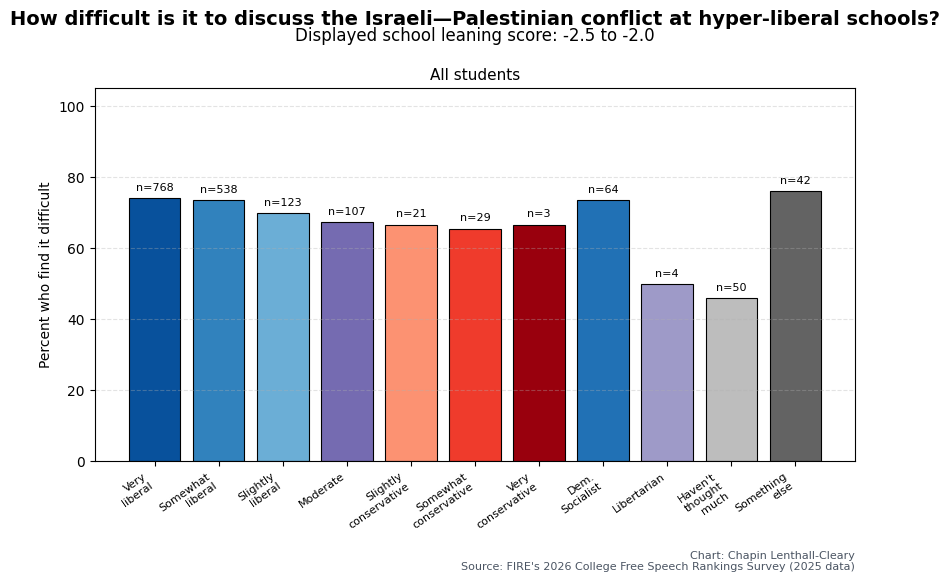

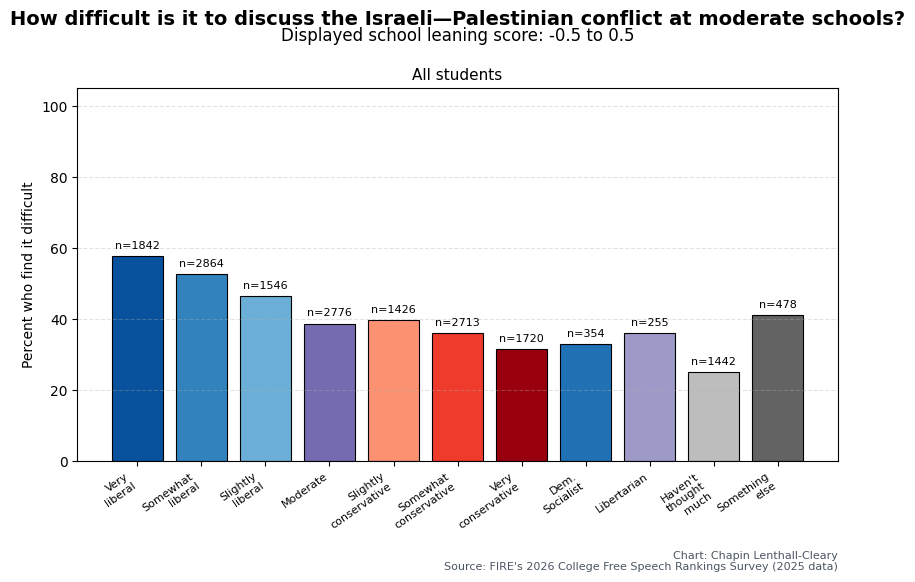

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Settings ---
INPUT_CSV    = "cfsrALL.csv"
SCHOOL_COL   = "schoolname"
IDEO_COL     = "ideo"
GENDER_COL   = "gender_bin"
DATAYEAR_COL = "datayear"

TARGET_YEAR  = 2025
TK_IPC_COL   = "tk_ipc"

# Only make these two figures
TARGET_BIN_LABEL = "2.0 to 2.5"
COMBINED_LOW = -0.5
COMBINED_HIGH = 0.5
COMBINED_LABEL = f"{COMBINED_LOW:.1f} to {COMBINED_HIGH:.1f} (combined)"

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Leaning-score bins
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0

# Ideology order/labels for bars
IDEO_ORDER = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
IDEO_LABELS = {
    1: "Very\nliberal",
    2: "Somewhat\nliberal",
    3: "Slightly\nliberal",
    4: "Moderate",
    5: "Slightly\nconservative",
    6: "Somewhat\nconservative",
    7: "Very\nconservative",
    8: "Dem.\nSocialist",
    9: "Libertarian",
    10: "Haven't\nthought\nmuch",
    11: "Something\nelse",
}

# Bar colors by ideology
IDEO_COLORS = {
    1: "#08519c",
    2: "#3182bd",
    3: "#6baed6",
    4: "#756bb1",
    5: "#fc9272",
    6: "#ef3b2c",
    7: "#99000d",
    8: "#2171b5",
    9: "#9e9ac8",
    10: "#bdbdbd",
    11: "#636363",
}

# Credits / layout
CREDITS_COLOR = "#4b5563"
SUPTITLE_Y_TOP = 0.972
SUPTITLE_Y_BOTTOM = 0.943
CREDITS_Y = 0.035
TIGHT_RECT = [0.06, 0.08, 0.98, 0.90]

# Color mapping for leaning bins (blue -> purple -> red)
CMAP_LR = LinearSegmentedColormap.from_list(
    "blue_purple_red",
    ["#084594", "#6a51a3", "#b10026"]
)


def leaning_val_to_color(score):
    if pd.isna(score):
        return "#9ca3af"
    t = (3.0 - score) / 6.0
    t = max(0.0, min(1.0, t))
    return CMAP_LR(t)


def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def _compute_school_leaning_scores(df):
    """
    Compute school leaning scores using ideologies 1-9 only.
    Ideologies 10 and 11 are included in the bar plots, but not in the
    school-leaning calculation.
    """
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1-9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)

    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")
    return leaning_score.reset_index()


def _build_bin_metadata():
    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}" for i in range(len(bin_edges) - 1)]
    bin_centers = [(bin_edges[i] + bin_edges[i + 1]) / 2.0 for i in range(len(bin_edges) - 1)]
    bin_center_map = dict(zip(bin_labels, bin_centers))
    bin_color_map = {label: leaning_val_to_color(center) for label, center in bin_center_map.items()}
    return bin_edges, bin_labels, bin_center_map, bin_color_map


def format_display_range_from_actual(actual_low, actual_high):
    vals = sorted([-actual_low, -actual_high])
    return f"{vals[0]:.1f} to {vals[1]:.1f}"


def place_suptitle_over_axes(fig, ax, top_line, bottom_line):
    bbox = ax.get_position()
    x_center = float((bbox.x0 + bbox.x1) / 2.0)

    fig.text(
        x_center, SUPTITLE_Y_TOP, top_line,
        ha="center", va="top",
        fontsize=14, fontweight="bold"
    )
    fig.text(
        x_center, SUPTITLE_Y_BOTTOM, bottom_line,
        ha="center", va="top",
        fontsize=12, fontweight="normal"
    )


def add_credits_aligned_to_axes(fig, ax, year):
    bbox = ax.get_position()
    x_right = float(bbox.x1)

    credits_text = (
        "Chart: Chapin Lenthall-Cleary\n"
        f"Source: FIRE's 2026 College Free Speech Rankings Survey ({year} data)"
    )

    fig.text(
        x_right, CREDITS_Y, credits_text,
        ha="right", va="bottom",
        fontsize=8, color=CREDITS_COLOR
    )


def _summarize_question(df_subset, question_col):
    rows = []
    for ide in IDEO_ORDER:
        valid_mask = (df_subset[IDEO_COL] == ide) & df_subset[question_col].isin([0, 1])
        n_valid = int(valid_mask.sum())
        n_yes = int((df_subset.loc[valid_mask, question_col] == 1).sum())
        pct_yes = 100.0 * n_yes / n_valid if n_valid > 0 else np.nan

        rows.append({
            "question": question_col,
            "ideology_code": ide,
            "ideology_label": IDEO_LABELS.get(ide, str(ide)),
            "n_valid": n_valid,
            "n_yes": n_yes,
            "pct_yes": pct_yes,
        })

    return pd.DataFrame(rows)


def _plot_bar_axis(ax, qdf, title):
    qdf = qdf.set_index("ideology_code").reindex(IDEO_ORDER).reset_index()

    x = np.arange(len(IDEO_ORDER))
    heights = qdf["pct_yes"].fillna(0).to_numpy()
    counts = qdf["n_valid"].to_numpy()
    xlabels = [IDEO_LABELS[i] for i in IDEO_ORDER]

    colors = []
    for ide, n in zip(IDEO_ORDER, counts):
        colors.append("#d1d5db" if n == 0 else IDEO_COLORS[ide])

    bars = ax.bar(x, heights, color=colors, edgecolor="black", linewidth=0.8)

    for bar, n, h in zip(bars, counts, heights):
        y = h + 1.5 if n > 0 else 1.5
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"n={n}",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=35, ha="right", fontsize=8)
    ax.set_ylim(0, 105)
    ax.set_ylabel('Percent who find it difficult')
    ax.grid(axis="y", linestyle="--", alpha=0.35)


def _plot_tk_ipc_overall(df_bin, school_type_label, actual_low, actual_high, year):
    fig, ax = plt.subplots(1, 1, figsize=(9.2, 6.0))

    qdf = _summarize_question(df_bin, TK_IPC_COL)
    _plot_bar_axis(ax, qdf, "All students")

    display_range = format_display_range_from_actual(actual_low, actual_high)

    fig.tight_layout(rect=TIGHT_RECT)
    place_suptitle_over_axes(
        fig,
        ax,
        f"How difficult is it to discuss the Israeli—Palestinian conflict at {school_type_label.lower()} schools?",
        f"Displayed school leaning score: {display_range}"
    )
    add_credits_aligned_to_axes(fig, ax, year)

    plt.show()
    plt.close(fig)


def generate_tk_ipc_overall_plots_for_year(df_all, year=2025):
    df = df_all.copy()
    df.columns = [c.strip() for c in df.columns]

    _require_cols(df, [SCHOOL_COL, IDEO_COL, GENDER_COL, DATAYEAR_COL, TK_IPC_COL])

    df[DATAYEAR_COL] = pd.to_numeric(df[DATAYEAR_COL], errors="coerce")
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    df[GENDER_COL] = pd.to_numeric(df[GENDER_COL], errors="coerce")

    df = df[df[DATAYEAR_COL] == year].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {year}.")

    # Compute school leaning scores
    leanings = _compute_school_leaning_scores(df)

    # Merge leaning score back to respondent-level data
    df_lean = df.merge(leanings, on=SCHOOL_COL, how="left")
    df_lean = df_lean[df_lean["leaning_score"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No respondents with a computed leaning_score after merging.")

    if df_lean[TK_IPC_COL].isin([0, 1]).sum() == 0:
        raise ValueError(f"No valid 0/1 responses found in '{TK_IPC_COL}' for {year}.")

    # Build bins
    bin_edges, _, _, _ = _build_bin_metadata()
    regular_bin_labels = [f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}" for i in range(len(bin_edges) - 1)]

    df_lean["leaning_bin"] = pd.cut(
        df_lean["leaning_score"],
        bins=bin_edges,
        labels=regular_bin_labels,
        include_lowest=True,
        right=True,
    )
    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No rows fall into the defined leaning bins.")

    # 1) Hyper-liberal schools: actual 2.0 to 2.5
    df_target = df_lean[df_lean["leaning_bin"] == TARGET_BIN_LABEL].copy()
    if df_target.empty:
        print(f"No rows found in bin {TARGET_BIN_LABEL} ({year}).")
    elif df_target[TK_IPC_COL].isin([0, 1]).sum() == 0:
        print(f"No valid {TK_IPC_COL} responses found in bin {TARGET_BIN_LABEL} ({year}).")
    else:
        _plot_tk_ipc_overall(
            df_bin=df_target,
            school_type_label="Hyper-liberal",
            actual_low=2.0,
            actual_high=2.5,
            year=year,
        )

    # 2) Moderate schools: combined actual -0.5 to 0.5
    df_combined = df_lean[
        df_lean["leaning_score"].between(COMBINED_LOW, COMBINED_HIGH, inclusive="both")
    ].copy()

    if df_combined.empty:
        print(f"No rows found for leaning_score in [{COMBINED_LOW:.1f}, {COMBINED_HIGH:.1f}] ({year}).")
    elif df_combined[TK_IPC_COL].isin([0, 1]).sum() == 0:
        print(f"No valid {TK_IPC_COL} responses found in combined center bin ({year}).")
    else:
        _plot_tk_ipC_overall = _plot_tk_ipc_overall
        _plot_tk_ipC_overall(
            df_bin=df_combined,
            school_type_label="Moderate",
            actual_low=COMBINED_LOW,
            actual_high=COMBINED_HIGH,
            year=year,
        )


# --- Run ---
df_all = pd.read_csv(INPUT_CSV)
generate_tk_ipc_overall_plots_for_year(df_all, year=TARGET_YEAR)

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_7869/4078892987.py:392: DtypeWarning: Columns (19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(INPUT_CSV)


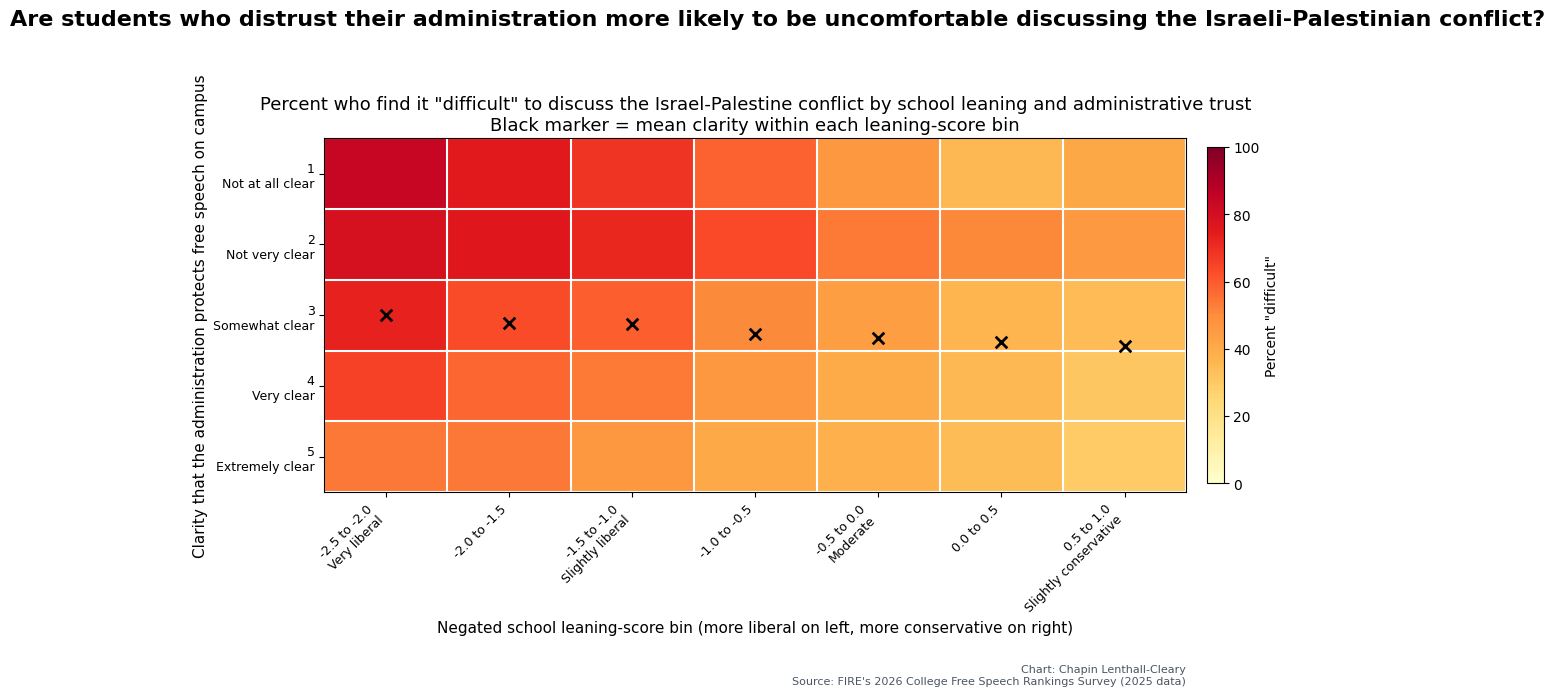

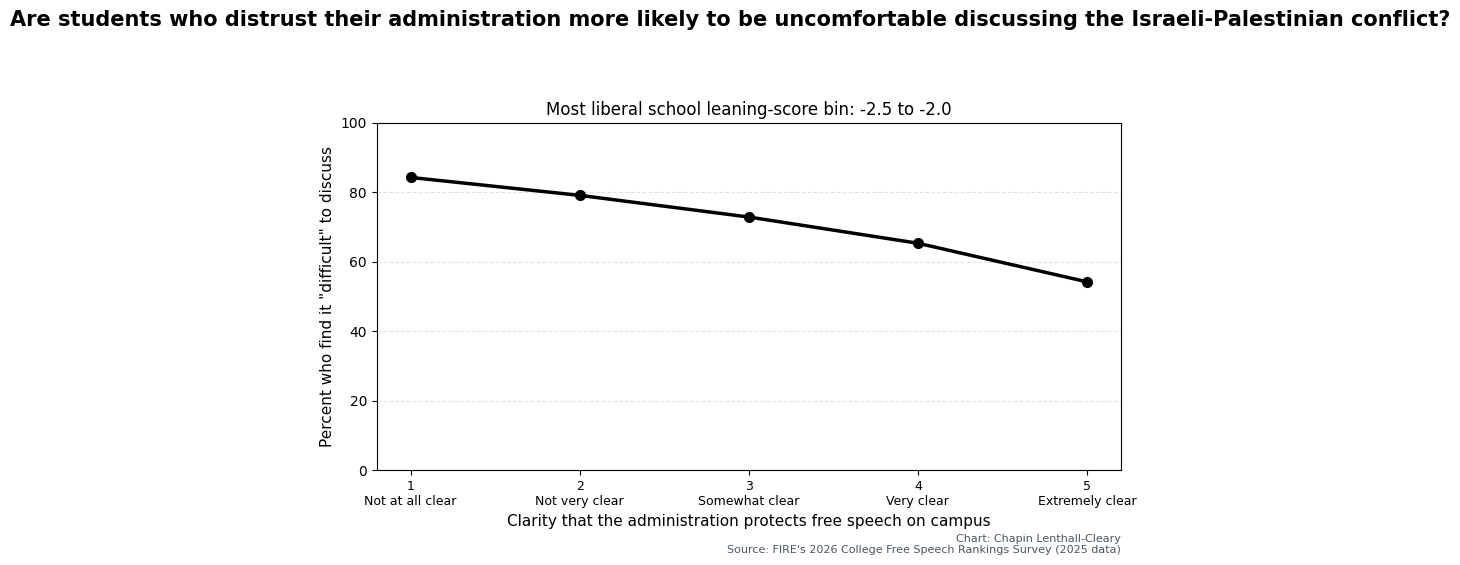

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
INPUT_CSV      = "cfsrALL.csv"
SCHOOL_COL     = "schoolname"
IDEO_COL       = "ideo"
DATAYEAR_COL   = "datayear"
ADMINCLEAR_COL = "adminclear"
TK_IPC_COL     = "tk_ipc"

TARGET_YEAR = 2025

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Leaning-score bins
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0

ADMINCLEAR_ORDER = [1, 2, 3, 4, 5]
ADMINCLEAR_LABELS = {
    1: "1\nNot at all clear",
    2: "2\nNot very clear",
    3: "3\nSomewhat clear",
    4: "4\nVery clear",
    5: "5\nExtremely clear",
}

# Ideology guide labels to merge into the main x-axis tick labels
IDEOLOGY_GUIDE = [
    (-3, "Very liberal"),
    (-2, "Liberal"),
    (-1, "Slightly liberal"),
    (0,  "Moderate"),
    (1,  "Slightly conservative"),
    (2,  "Conservative"),
    (3,  "Very conservative"),
]

# Suptitle / credits
SUPTITLE_Y = 0.97
CREDITS_Y = 0.03
CREDITS_COLOR = "#4b5563"


def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def _compute_school_leaning_scores(df):
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1–9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)

    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")

    # Negate so liberal schools are negative (left), conservative schools positive (right)
    leaning_score = (-1.0 * leaning_score).rename("leaning_score")

    return leaning_score.reset_index()


def _build_bin_metadata():
    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [
        f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}"
        for i in range(len(bin_edges) - 1)
    ]
    bin_centers = [
        (bin_edges[i] + bin_edges[i + 1]) / 2.0
        for i in range(len(bin_edges) - 1)
    ]
    bin_center_map = dict(zip(bin_labels, bin_centers))
    return bin_edges, bin_labels, bin_center_map


def _make_heatmap_matrices(df_subset, bin_labels):
    """
    Rows = adminclear 1..5
    Cols = leaning-score bins
    Values = percent difficult on tk_ipc
    """
    n_rows = len(ADMINCLEAR_ORDER)
    n_cols = len(bin_labels)

    pct_mat = np.full((n_rows, n_cols), np.nan, dtype=float)
    n_mat = np.zeros((n_rows, n_cols), dtype=int)

    for i, admin_val in enumerate(ADMINCLEAR_ORDER):
        for j, bin_label in enumerate(bin_labels):
            mask = (
                (df_subset["leaning_bin"] == bin_label) &
                (df_subset[ADMINCLEAR_COL] == admin_val) &
                (df_subset[TK_IPC_COL].isin([0, 1]))
            )

            n_valid = int(mask.sum())
            n_difficult = int((df_subset.loc[mask, TK_IPC_COL] == 1).sum())

            n_mat[i, j] = n_valid

            if n_valid > 0:
                pct_mat[i, j] = 100.0 * n_difficult / n_valid

    return pct_mat, n_mat


def _compute_mean_adminclear_by_bin(df_subset, bin_labels):
    means = []
    for bin_label in bin_labels:
        mask = (
            (df_subset["leaning_bin"] == bin_label) &
            (df_subset[ADMINCLEAR_COL].isin(ADMINCLEAR_ORDER))
        )
        if mask.sum() > 0:
            means.append(df_subset.loc[mask, ADMINCLEAR_COL].mean())
        else:
            means.append(np.nan)
    return np.array(means, dtype=float)


def _augment_bin_labels_with_ideology(bin_labels, bin_center_map):
    """
    Add ideology labels directly onto the main x-axis tick labels at the
    nearest matching displayed bin.
    """
    used_centers = np.array([bin_center_map[b] for b in bin_labels], dtype=float)
    augmented = list(bin_labels)

    used_positions = set()
    for score, label in IDEOLOGY_GUIDE:
        if len(used_centers) == 0:
            continue
        pos = int(np.argmin(np.abs(used_centers - score)))
        if pos in used_positions:
            continue
        used_positions.add(pos)
        augmented[pos] = f"{augmented[pos]}\n{label}"

    return augmented


def _draw_heatmap_with_adminclear_marker(ax, pct_mat, bin_labels, mean_adminclear, bin_center_map):
    masked = np.ma.masked_invalid(pct_mat)
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color="#f3f4f6")

    im = ax.imshow(masked, aspect="auto", vmin=0, vmax=100, cmap=cmap, origin="upper")

    xticklabels = _augment_bin_labels_with_ideology(bin_labels, bin_center_map)

    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(ADMINCLEAR_ORDER)))
    ax.set_yticklabels([ADMINCLEAR_LABELS[i] for i in ADMINCLEAR_ORDER], fontsize=9)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, len(bin_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ADMINCLEAR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Overlay average adminclear marker
    x = np.arange(len(bin_labels))
    y = mean_adminclear - 1.0  # convert 1..5 scale to row coordinates 0..4

    valid = ~np.isnan(y)
    if valid.any():
        ax.scatter(
            x[valid],
            y[valid],
            marker="x",
            s=70,
            linewidths=2,
            color="black",
            zorder=5,
        )

    return im


def _compute_adminclear_line_for_bin(df_subset, bin_label):
    rows = []
    for admin_val in ADMINCLEAR_ORDER:
        mask = (
            (df_subset["leaning_bin"] == bin_label) &
            (df_subset[ADMINCLEAR_COL] == admin_val) &
            (df_subset[TK_IPC_COL].isin([0, 1]))
        )
        n_valid = int(mask.sum())
        n_difficult = int((df_subset.loc[mask, TK_IPC_COL] == 1).sum())
        pct_difficult = 100.0 * n_difficult / n_valid if n_valid > 0 else np.nan

        rows.append({
            "adminclear": admin_val,
            "label": ADMINCLEAR_LABELS[admin_val],
            "n_valid": n_valid,
            "n_difficult": n_difficult,
            "pct_difficult": pct_difficult,
        })

    return pd.DataFrame(rows)


def add_credits_aligned_to_axes(fig, ax, year):
    bbox = ax.get_position()
    x_right = float(bbox.x1)

    credits_text = (
        "Chart: Chapin Lenthall-Cleary\n"
        f"Source: FIRE's 2026 College Free Speech Rankings Survey ({year} data)"
    )

    fig.text(
        x_right,
        CREDITS_Y,
        credits_text,
        ha="right",
        va="bottom",
        fontsize=8,
        color=CREDITS_COLOR
    )


def _plot_lowest_bin_adminclear_line(df_lean, lowest_bin_label, year):
    line_df = _compute_adminclear_line_for_bin(df_lean, lowest_bin_label)

    fig, ax = plt.subplots(figsize=(8.5, 5.8))

    x = np.arange(len(line_df))
    y = line_df["pct_difficult"].to_numpy(dtype=float)
    valid = np.isfinite(y)

    ax.plot(
        x[valid],
        y[valid],
        marker="o",
        linewidth=2.5,
        markersize=7,
        color="black",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(line_df["label"], fontsize=9)
    ax.set_ylim(0, 100)
    ax.set_ylabel('Percent who find it "difficult" to discuss', fontsize=11)
    ax.set_xlabel("Clarity that the administration protects free speech on campus", fontsize=11)
    ax.set_title(
        f'Most liberal school leaning-score bin: {lowest_bin_label}',
        fontsize=12,
    )
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    fig.suptitle(
        "Are students who distrust their administration more likely to be uncomfortable discussing the Israeli-Palestinian conflict?",
        fontsize=15,
        fontweight="bold",
        y=SUPTITLE_Y,
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.90])
    add_credits_aligned_to_axes(fig, ax, year)
    plt.show()
    plt.close(fig)


def make_adminclear_by_leaning_heatmap(df_all, year=2025):
    df = df_all.copy()
    df.columns = [c.strip() for c in df.columns]

    _require_cols(df, [SCHOOL_COL, IDEO_COL, DATAYEAR_COL, ADMINCLEAR_COL, TK_IPC_COL])

    # Numeric coercion
    for col in [IDEO_COL, DATAYEAR_COL, ADMINCLEAR_COL, TK_IPC_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Filter year
    df = df[df[DATAYEAR_COL] == year].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {year}.")

    # Compute school leaning scores
    leanings = _compute_school_leaning_scores(df)

    # Merge back to respondent-level data
    df_lean = df.merge(leanings, on=SCHOOL_COL, how="left")
    df_lean = df_lean[df_lean["leaning_score"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No respondents with a computed leaning_score after merging.")

    # Keep only valid adminclear rows for the heatmap
    df_lean = df_lean[df_lean[ADMINCLEAR_COL].isin(ADMINCLEAR_ORDER)].copy()
    if df_lean.empty:
        raise ValueError("No valid rows after filtering adminclear to 1–5.")

    # Build leaning-score bins
    bin_edges, all_bin_labels, bin_center_map = _build_bin_metadata()

    df_lean["leaning_bin"] = pd.cut(
        df_lean["leaning_score"],
        bins=bin_edges,
        labels=all_bin_labels,
        include_lowest=True,
        right=True,
    )

    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No rows fall into the defined leaning bins.")

    # Keep only bins that actually appear, ordered left->right:
    # more liberal (negative) on left, more conservative (positive) on right
    bin_counts = df_lean["leaning_bin"].value_counts().reindex(all_bin_labels)
    used_bin_labels = [b for b in all_bin_labels if bin_counts.get(b, 0) > 0]
    if not used_bin_labels:
        raise ValueError("No leaning-score bins have any data.")

    used_bin_labels = sorted(
        used_bin_labels,
        key=lambda b: bin_center_map[b]
    )

    pct_mat, n_mat = _make_heatmap_matrices(df_lean, used_bin_labels)
    mean_adminclear = _compute_mean_adminclear_by_bin(df_lean, used_bin_labels)

    fig_width = max(12, 1.1 * len(used_bin_labels))
    fig, ax = plt.subplots(figsize=(fig_width, 7.2))

    im = _draw_heatmap_with_adminclear_marker(
        ax=ax,
        pct_mat=pct_mat,
        bin_labels=used_bin_labels,
        mean_adminclear=mean_adminclear,
        bin_center_map=bin_center_map,
    )

    ax.set_xlabel(
        "Negated school leaning-score bin (more liberal on left, more conservative on right)",
        fontsize=11
    )
    ax.set_ylabel("Clarity that the administration protects free speech on campus", fontsize=11)
    ax.set_title(
        'Percent who find it "difficult" to discuss the Israel-Palestine conflict by school leaning and administrative trust\n'
        "Black marker = mean clarity within each leaning-score bin",
        fontsize=13,
    )

    fig.suptitle(
        "Are students who distrust their administration more likely to be uncomfortable discussing the Israeli-Palestinian conflict?",
        fontsize=16,
        fontweight="bold",
        y=SUPTITLE_Y,
    )

    cbar = fig.colorbar(im, ax=ax, shrink=0.95, pad=0.02)
    cbar.set_label('Percent "difficult"', fontsize=10)

    plt.tight_layout(rect=[0, 0.08, 1, 0.92])
    add_credits_aligned_to_axes(fig, ax, year)
    plt.show()
    plt.close(fig)

    # Additional line graph for the lowest leaning-score bin
    lowest_bin_label = used_bin_labels[0]
    _plot_lowest_bin_adminclear_line(df_lean, lowest_bin_label, year)


# --- Run ---
df_all = pd.read_csv(INPUT_CSV)
make_adminclear_by_leaning_heatmap(df_all, year=TARGET_YEAR)

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_7869/2021175241.py:179: DtypeWarning: Columns (19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CFSR_CSV)


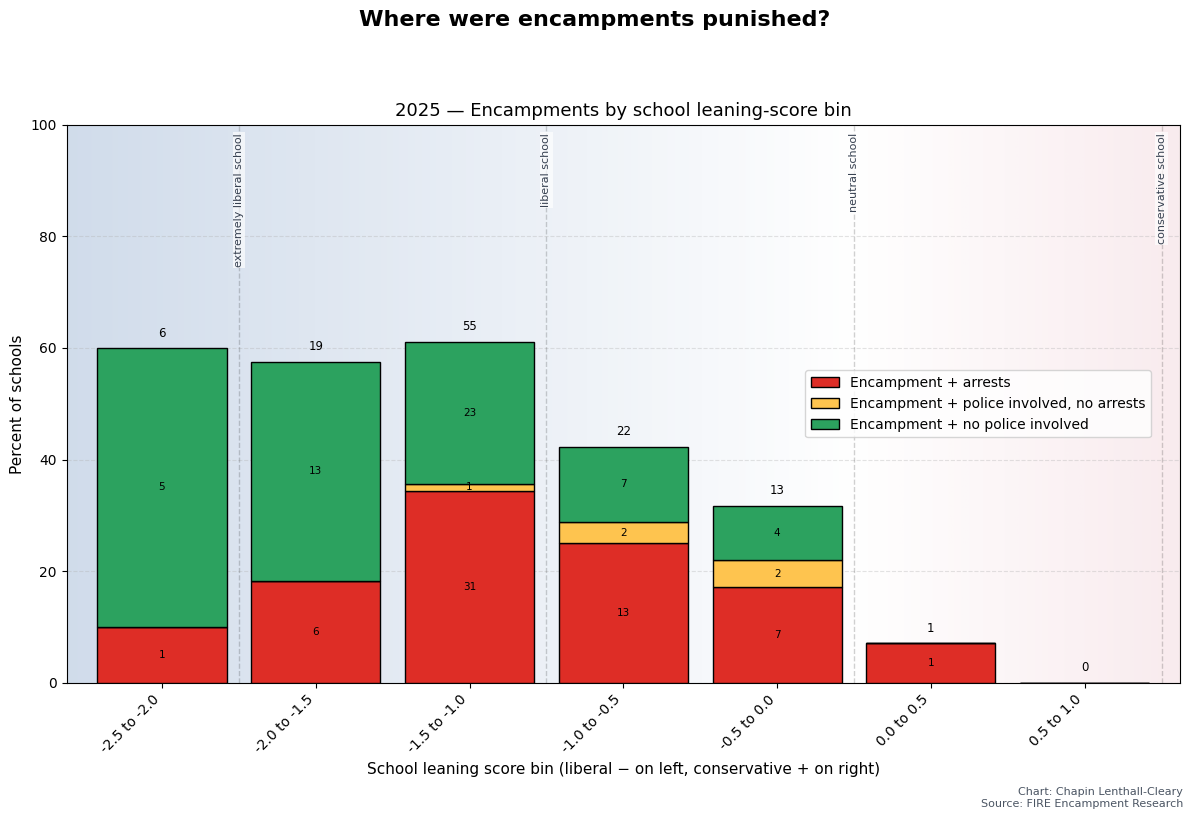

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Settings ---
CFSR_CSV       = "cfsrALL.csv"
ENC_CSV        = "enc_updated_verified.csv"

SCHOOL_COL     = "schoolname"
IDEO_COL       = "ideo"
DATAYEAR_COL   = "datayear"

ENC_SCHOOL_COL = "University"
ENCAMP_COL     = "Encampment?"
ARREST_COL     = "Arrests?"
POLICE_COL     = "Police Involved?"

TARGET_YEAR = 2025

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Leaning-score bins
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0
X_BUFFER = 0.10
BG_ALPHA = 0.22

# Colors: less severe -> more severe
COLOR_NO_POLICE = "#2ca25f"         # green
COLOR_POLICE_NO_ARREST = "#fec44f"  # yellow
COLOR_ARRESTS = "#de2d26"           # red

# Background gradient for school leaning
CMAP_BWR = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["#084594", "#ffffff", "#b10026"]
)

# Reference labels for school leaning
LEANING_REF_LABELS = [
    (-2, "extremely liberal school"),
    (-1, "liberal school"),
    (0,  "neutral school"),
    (1,  "conservative school"),
    (2,  "extremely conservative school"),
]

# Credit label
CREDITS_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE Encampment Research"
)
CREDITS_COLOR = "#4b5563"
SUPTITLE_Y = 0.97
CREDITS_Y = 0.03


def _require_cols(df, cols, df_name="DataFrame"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {df_name}: {missing}")


def _to_bool01(series):
    """
    Convert a column to 0/1 where possible.
    Handles common forms like:
      1/0, yes/no, y/n, true/false, t/f
    Unrecognized values become NaN.
    """
    s = series.copy()

    s_num = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index, dtype="float")

    out.loc[s_num == 1] = 1
    out.loc[s_num == 0] = 0

    s_str = s.astype(str).str.strip().str.lower()
    yes_vals = {"yes", "y", "true", "t", "1"}
    no_vals = {"no", "n", "false", "f", "0"}

    out.loc[s_str.isin(yes_vals)] = 1
    out.loc[s_str.isin(no_vals)] = 0

    return out


def add_leaning_background_gradient(ax, xlim_min: float, xlim_max: float, alpha: float = BG_ALPHA):
    """Left->right gradient keyed to school leaning score: -3 blue, 0 white, +3 red."""
    ymin, ymax = ax.get_ylim()
    xs = np.linspace(xlim_min, xlim_max, 512)
    Z = np.tile(xs, (2, 1))
    ax.imshow(
        Z,
        extent=[xlim_min, xlim_max, ymin, ymax],
        aspect="auto",
        origin="lower",
        cmap=CMAP_BWR,
        vmin=-3, vmax=3,
        alpha=alpha,
        zorder=0,
    )


def add_leaning_reference_labels(ax, xlim_min: float, xlim_max: float):
    """Vertical reference lines + labels at x = -2,-1,0,1,2 if within view."""
    for x, label in LEANING_REF_LABELS:
        if xlim_min <= x <= xlim_max:
            ax.axvline(x, color="black", alpha=0.18, linestyle="--", linewidth=1.0, zorder=1)
            ax.text(
                x, 0.985, label,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top",
                fontsize=8, color="#374151",
                rotation=90,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.0),
                zorder=2,
            )


def _compute_school_leaning_scores(df):
    """
    Compute school leaning score and NEGATE it so:
      liberal schools -> negative
      conservative schools -> positive
    """
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1-9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)

    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")

    # Invert so liberal = negative, conservative = positive
    leaning_score = (-1.0 * leaning_score).rename("leaning_score")

    return leaning_score.reset_index()


def _build_bin_metadata():
    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [
        f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}"
        for i in range(len(bin_edges) - 1)
    ]
    bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    return bin_edges, bin_labels, bin_mids


def _segment_label(count):
    return f"{count}"


def make_encampment_stacked_bar():
    # -----------------------------
    # 1) Read cfsrALL and compute school leanings for TARGET_YEAR
    # -----------------------------
    df = pd.read_csv(CFSR_CSV)
    df.columns = [c.strip() for c in df.columns]

    _require_cols(df, [SCHOOL_COL, IDEO_COL, DATAYEAR_COL], "cfsrALL.csv")

    df[DATAYEAR_COL] = pd.to_numeric(df[DATAYEAR_COL], errors="coerce")
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    df[SCHOOL_COL] = df[SCHOOL_COL].astype(str).str.strip()

    df = df[df[DATAYEAR_COL] == TARGET_YEAR].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {TARGET_YEAR} in {CFSR_CSV}.")

    leaning_df = _compute_school_leaning_scores(df)
    leaning_df[SCHOOL_COL] = leaning_df[SCHOOL_COL].astype(str).str.strip()

    bin_edges, bin_labels, bin_mids = _build_bin_metadata()
    bin_mid_map = dict(zip(bin_labels, bin_mids))

    leaning_df["leaning_bin"] = pd.cut(
        leaning_df["leaning_score"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
        right=True,
    )
    leaning_df = leaning_df[leaning_df["leaning_bin"].notna()].copy()

    if leaning_df.empty:
        raise ValueError("No schools fall into the defined leaning-score bins.")

    # -----------------------------
    # 2) Read updated enc file and normalize columns
    # -----------------------------
    enc = pd.read_csv(ENC_CSV)
    enc.columns = [c.strip() for c in enc.columns]

    _require_cols(
        enc,
        [ENC_SCHOOL_COL, ENCAMP_COL, ARREST_COL, POLICE_COL],
        ENC_CSV
    )

    enc[ENC_SCHOOL_COL] = enc[ENC_SCHOOL_COL].astype(str).str.strip()

    enc["encampment_01"] = _to_bool01(enc[ENCAMP_COL])
    enc["arrests_01"] = _to_bool01(enc[ARREST_COL])
    enc["police_01"] = _to_bool01(enc[POLICE_COL])

    # Collapse duplicates to one row per school
    enc_school = (
        enc.groupby(ENC_SCHOOL_COL, dropna=True)[["encampment_01", "arrests_01", "police_01"]]
        .max()
        .reset_index()
    )

    # If no encampment, force police/arrests to 0 for plotting logic
    enc_school.loc[enc_school["encampment_01"] != 1, ["arrests_01", "police_01"]] = 0

    # -----------------------------
    # 3) Merge leanings with updated enc school names
    # -----------------------------
    school_df = leaning_df.merge(
        enc_school,
        left_on=SCHOOL_COL,
        right_on=ENC_SCHOOL_COL,
        how="left"
    )

    # Keep only matched schools
    school_df = school_df[school_df["encampment_01"].notna()].copy()
    if school_df.empty:
        raise ValueError(
            f"No schools matched between {CFSR_CSV} {SCHOOL_COL} and {ENC_CSV} {ENC_SCHOOL_COL}."
        )

    school_df["arrests_01"] = school_df["arrests_01"].fillna(0)
    school_df["police_01"] = school_df["police_01"].fillna(0)

    # -----------------------------
    # 4) Summarize by leaning bin
    # -----------------------------
    rows = []

    for bin_label in bin_labels:
        df_bin = school_df[school_df["leaning_bin"] == bin_label].copy()
        if df_bin.empty:
            continue

        by_school = (
            df_bin.groupby(SCHOOL_COL, dropna=True)[["encampment_01", "arrests_01", "police_01"]]
            .max()
            .reset_index()
        )

        n_schools = len(by_school)

        n_enc_arrests = int(
            ((by_school["encampment_01"] == 1) & (by_school["arrests_01"] == 1)).sum()
        )

        n_enc_police_no_arrests = int(
            (
                (by_school["encampment_01"] == 1) &
                (by_school["arrests_01"] != 1) &
                (by_school["police_01"] == 1)
            ).sum()
        )

        n_enc_no_police = int(
            (
                (by_school["encampment_01"] == 1) &
                (by_school["arrests_01"] != 1) &
                (by_school["police_01"] != 1)
            ).sum()
        )

        n_enc_total = n_enc_arrests + n_enc_police_no_arrests + n_enc_no_police

        pct_enc_arrests = 100.0 * n_enc_arrests / n_schools if n_schools > 0 else np.nan
        pct_enc_police_no_arrests = 100.0 * n_enc_police_no_arrests / n_schools if n_schools > 0 else np.nan
        pct_enc_no_police = 100.0 * n_enc_no_police / n_schools if n_schools > 0 else np.nan
        pct_enc_total = 100.0 * n_enc_total / n_schools if n_schools > 0 else np.nan

        pct_bar_arrests = 100.0 * n_enc_arrests / n_enc_total if n_enc_total > 0 else 0.0
        pct_bar_police_no_arrests = 100.0 * n_enc_police_no_arrests / n_enc_total if n_enc_total > 0 else 0.0
        pct_bar_no_police = 100.0 * n_enc_no_police / n_enc_total if n_enc_total > 0 else 0.0

        rows.append({
            "leaning_bin": bin_label,
            "bin_mid": bin_mid_map[bin_label],
            "n_schools": n_schools,
            "n_enc_arrests": n_enc_arrests,
            "n_enc_police_no_arrests": n_enc_police_no_arrests,
            "n_enc_no_police": n_enc_no_police,
            "n_enc_total": n_enc_total,
            "pct_enc_arrests": pct_enc_arrests,
            "pct_enc_police_no_arrests": pct_enc_police_no_arrests,
            "pct_enc_no_police": pct_enc_no_police,
            "pct_enc_total": pct_enc_total,
            "pct_bar_arrests": pct_bar_arrests,
            "pct_bar_police_no_arrests": pct_bar_police_no_arrests,
            "pct_bar_no_police": pct_bar_no_police,
        })

    summary = pd.DataFrame(rows)
    if summary.empty:
        raise ValueError("No leaning-score bins had matched school data to plot.")

    # -----------------------------
    # 5) Plot stacked bars on numeric leaning-score x-axis
    # -----------------------------
    x = summary["bin_mid"].to_numpy(dtype=float)
    width = 0.42

    fig, ax = plt.subplots(figsize=(max(12, 1.15 * len(summary)), 8.5))
    ax.set_axisbelow(True)

    # Most severe on bottom, least severe on top
    bars1 = ax.bar(
        x,
        summary["pct_enc_arrests"],
        width=width,
        label="Encampment + arrests",
        color=COLOR_ARRESTS,
        edgecolor="black",
        zorder=3,
    )

    bars2 = ax.bar(
        x,
        summary["pct_enc_police_no_arrests"],
        width=width,
        bottom=summary["pct_enc_arrests"],
        label="Encampment + police involved, no arrests",
        color=COLOR_POLICE_NO_ARREST,
        edgecolor="black",
        zorder=3,
    )

    bars3 = ax.bar(
        x,
        summary["pct_enc_no_police"],
        width=width,
        bottom=summary["pct_enc_arrests"] + summary["pct_enc_police_no_arrests"],
        label="Encampment + no police involved",
        color=COLOR_NO_POLICE,
        edgecolor="black",
        zorder=3,
    )

    xticklabels = [
        f"{b}"
        for b, n in zip(summary["leaning_bin"], summary["n_schools"])
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, rotation=45, ha="right")

    ax.set_ylabel("Percent of schools", fontsize=11)
    ax.set_xlabel("School leaning score bin (liberal − on left, conservative + on right)", fontsize=11)
    ax.set_ylim(0, 100)

    # Gradient and ideology reference labels, trimmed to plotted-bar span
    xlim_min = float(x.min() - width / 2.0 - X_BUFFER)
    xlim_max = float(x.max() + width / 2.0 + X_BUFFER)
    ax.set_xlim(xlim_min, xlim_max)

    add_leaning_background_gradient(ax, xlim_min, xlim_max, alpha=BG_ALPHA)
    add_leaning_reference_labels(ax, xlim_min, xlim_max)

    ax.set_title(
        f"{TARGET_YEAR} — Encampments by school leaning-score bin",
        fontsize=13
    )
    fig.suptitle("Where were encampments punished?", fontsize=16, fontweight="bold", y=SUPTITLE_Y)

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(loc="center right", bbox_to_anchor=(0.98, 0.5))

    # Segment labels: count only
    for rect, count, pct_school in zip(
        bars1,
        summary["n_enc_arrests"],
        summary["pct_enc_arrests"],
    ):
        if pct_school > 0:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + rect.get_height() / 2,
                _segment_label(count),
                ha="center",
                va="center",
                fontsize=7.5,
                zorder=4,
            )

    for rect, bottom, count, pct_school in zip(
        bars2,
        summary["pct_enc_arrests"],
        summary["n_enc_police_no_arrests"],
        summary["pct_enc_police_no_arrests"],
    ):
        if pct_school > 0:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                bottom + pct_school / 2,
                _segment_label(count),
                ha="center",
                va="center",
                fontsize=7.5,
                zorder=4,
            )

    for rect, bottom, count, pct_school in zip(
        bars3,
        summary["pct_enc_arrests"] + summary["pct_enc_police_no_arrests"],
        summary["n_enc_no_police"],
        summary["pct_enc_no_police"],
    ):
        if pct_school > 0:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                bottom + pct_school / 2,
                _segment_label(count),
                ha="center",
                va="center",
                fontsize=7.5,
                zorder=4,
            )

    # Total label at top of each bar: count only
    for xi, total_count, total_pct in zip(
        x,
        summary["n_enc_total"],
        summary["pct_enc_total"]
    ):
        ax.text(
            xi,
            total_pct + 1.5,
            f"{total_count}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            zorder=4,
        )

    # Credit label
    fig.text(
        0.99, CREDITS_Y, CREDITS_TEXT,
        ha="right", va="bottom",
        fontsize=8, color=CREDITS_COLOR
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()

    return summary


# --- Run ---
summary_df = make_encampment_stacked_bar()

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_7869/1174113433.py:140: DtypeWarning: Columns (19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_CSV)


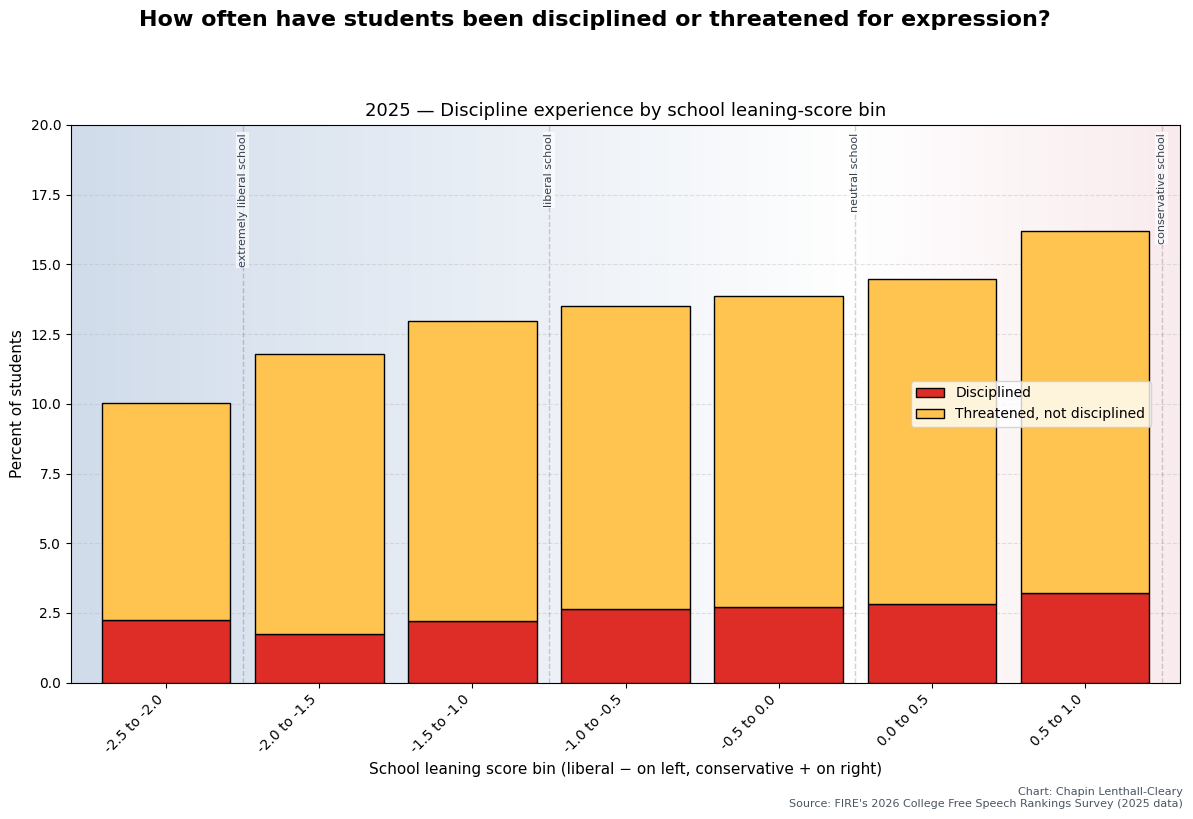

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Settings ---
INPUT_CSV      = "cfsrALL.csv"
SCHOOL_COL     = "schoolname"
IDEO_COL       = "ideo"
DATAYEAR_COL   = "datayear"
DISCIPLINE_COL = "discipline"

TARGET_YEAR = 2025

# Leaning-score weights
WEIGHTS = {
    1: 3,
    2: 2,
    3: 1,
    4: 0,
    5: -1,
    6: -2,
    7: -3,
    8: 3,
    9: 0,
}

# Leaning-score bins
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0
X_BUFFER = 0.10
BG_ALPHA = 0.22

# Colors
COLOR_THREATENED = "#fec44f"   # yellow
COLOR_DISCIPLINED = "#de2d26"  # red

# Background gradient for school leaning
CMAP_BWR = LinearSegmentedColormap.from_list(
    "blue_white_red",
    ["#084594", "#ffffff", "#b10026"]
)

# Reference labels for school leaning
LEANING_REF_LABELS = [
    (-2, "extremely liberal school"),
    (-1, "liberal school"),
    (0,  "neutral school"),
    (1,  "conservative school"),
    (2,  "extremely conservative school"),
]

# Discipline coding
DISCIPLINE_DISCIPLINED = 1
DISCIPLINE_THREATENED = 2
DISCIPLINE_NEITHER = 3
DISCIPLINE_VALID = [1, 2, 3]

# Credit label
CREDITS_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
CREDITS_COLOR = "#4b5563"
SUPTITLE_Y = 0.97
CREDITS_Y = 0.03


def _require_cols(df, cols, df_name="DataFrame"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {df_name}: {missing}")


def add_leaning_background_gradient(ax, xlim_min: float, xlim_max: float, alpha: float = BG_ALPHA):
    ymin, ymax = ax.get_ylim()
    xs = np.linspace(xlim_min, xlim_max, 512)
    Z = np.tile(xs, (2, 1))
    ax.imshow(
        Z,
        extent=[xlim_min, xlim_max, ymin, ymax],
        aspect="auto",
        origin="lower",
        cmap=CMAP_BWR,
        vmin=-3, vmax=3,
        alpha=alpha,
        zorder=0,
    )


def add_leaning_reference_labels(ax, xlim_min: float, xlim_max: float):
    for x, label in LEANING_REF_LABELS:
        if xlim_min <= x <= xlim_max:
            ax.axvline(x, color="black", alpha=0.18, linestyle="--", linewidth=1.0, zorder=1)
            ax.text(
                x, 0.985, label,
                transform=ax.get_xaxis_transform(),
                ha="center", va="top",
                fontsize=8, color="#374151",
                rotation=90,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=1.0),
                zorder=2,
            )


def _compute_school_leaning_scores(df):
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1-9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)

    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")

    # Invert so liberal = negative, conservative = positive
    leaning_score = (-1.0 * leaning_score).rename("leaning_score")

    return leaning_score.reset_index()


def _build_bin_metadata():
    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [
        f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}"
        for i in range(len(bin_edges) - 1)
    ]
    bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    return bin_edges, bin_labels, bin_mids


def make_discipline_stacked_bar():
    # 1) Read student data and compute school leanings
    df = pd.read_csv(INPUT_CSV)
    df.columns = [c.strip() for c in df.columns]

    _require_cols(df, [SCHOOL_COL, IDEO_COL, DATAYEAR_COL, DISCIPLINE_COL], "cfsrALL.csv")

    df[DATAYEAR_COL] = pd.to_numeric(df[DATAYEAR_COL], errors="coerce")
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    df[DISCIPLINE_COL] = pd.to_numeric(df[DISCIPLINE_COL], errors="coerce")
    df[SCHOOL_COL] = df[SCHOOL_COL].astype(str).str.strip()

    df = df[df[DATAYEAR_COL] == TARGET_YEAR].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {TARGET_YEAR} in {INPUT_CSV}.")

    leaning_df = _compute_school_leaning_scores(df)
    leaning_df[SCHOOL_COL] = leaning_df[SCHOOL_COL].astype(str).str.strip()

    bin_edges, bin_labels, bin_mids = _build_bin_metadata()
    bin_mid_map = dict(zip(bin_labels, bin_mids))

    leaning_df["leaning_bin"] = pd.cut(
        leaning_df["leaning_score"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
        right=True,
    )
    leaning_df = leaning_df[leaning_df["leaning_bin"].notna()].copy()

    if leaning_df.empty:
        raise ValueError("No schools fall into the defined leaning-score bins.")

    # 2) Merge school leanings onto respondent-level rows
    df_lean = df.merge(
        leaning_df[[SCHOOL_COL, "leaning_score", "leaning_bin"]],
        on=SCHOOL_COL,
        how="left"
    )
    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()

    if df_lean.empty:
        raise ValueError("No respondents matched to a school leaning-score bin.")

    # Keep only valid discipline responses
    df_lean = df_lean[df_lean[DISCIPLINE_COL].isin(DISCIPLINE_VALID)].copy()
    if df_lean.empty:
        raise ValueError("No valid discipline responses (1–3) found for the selected year.")

    # 3) Summarize by leaning bin
    rows = []

    for bin_label in bin_labels:
        df_bin = df_lean[df_lean["leaning_bin"] == bin_label].copy()
        if df_bin.empty:
            continue

        n_students = len(df_bin)

        n_disciplined = int((df_bin[DISCIPLINE_COL] == DISCIPLINE_DISCIPLINED).sum())
        n_threatened = int((df_bin[DISCIPLINE_COL] == DISCIPLINE_THREATENED).sum())

        pct_disciplined = 100.0 * n_disciplined / n_students if n_students > 0 else np.nan
        pct_threatened = 100.0 * n_threatened / n_students if n_students > 0 else np.nan

        rows.append({
            "leaning_bin": bin_label,
            "bin_mid": bin_mid_map[bin_label],
            "pct_disciplined": pct_disciplined,
            "pct_threatened": pct_threatened,
        })

    summary = pd.DataFrame(rows)
    if summary.empty:
        raise ValueError("No leaning-score bins had valid discipline data to plot.")

    # 4) Plot stacked bars on numeric leaning-score x-axis
    x = summary["bin_mid"].to_numpy(dtype=float)
    width = 0.42

    fig, ax = plt.subplots(figsize=(max(12, 1.15 * len(summary)), 8.5))
    ax.set_axisbelow(True)

    bars1 = ax.bar(
        x,
        summary["pct_disciplined"],
        width=width,
        label="Disciplined",
        color=COLOR_DISCIPLINED,
        edgecolor="black",
        zorder=3,
    )

    bars2 = ax.bar(
        x,
        summary["pct_threatened"],
        width=width,
        bottom=summary["pct_disciplined"],
        label="Threatened, not disciplined",
        color=COLOR_THREATENED,
        edgecolor="black",
        zorder=3,
    )

    xticklabels = [f"{b}" for b in summary["leaning_bin"]]
    ax.set_xticks(x)
    ax.set_xticklabels(xticklabels, rotation=45, ha="right")

    ax.set_ylabel("Percent of students", fontsize=11)
    ax.set_xlabel("School leaning score bin (liberal − on left, conservative + on right)", fontsize=11)
    ax.set_ylim(0, 20)

    xlim_min = float(x.min() - width / 2.0 - X_BUFFER)
    xlim_max = float(x.max() + width / 2.0 + X_BUFFER)
    ax.set_xlim(xlim_min, xlim_max)

    add_leaning_background_gradient(ax, xlim_min, xlim_max, alpha=BG_ALPHA)
    add_leaning_reference_labels(ax, xlim_min, xlim_max)

    ax.set_title(
        f"{TARGET_YEAR} — Discipline experience by school leaning-score bin",
        fontsize=13
    )
    fig.suptitle(
        "How often have students been disciplined or threatened for expression?",
        fontsize=16,
        fontweight="bold",
        y=SUPTITLE_Y,
    )

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(loc="center right", bbox_to_anchor=(0.98, 0.5))

    fig.text(
        0.99, CREDITS_Y, CREDITS_TEXT,
        ha="right", va="bottom",
        fontsize=8, color=CREDITS_COLOR
    )

    plt.tight_layout(rect=[0, 0.05, 1, 0.92])
    plt.show()

    return summary


# --- Run ---
summary_df = make_discipline_stacked_bar()

In [7]:
#some select plots that weren't in the article, but I made in the research for it

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_7869/325652981.py:245: DtypeWarning: Columns (19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(INPUT_CSV)


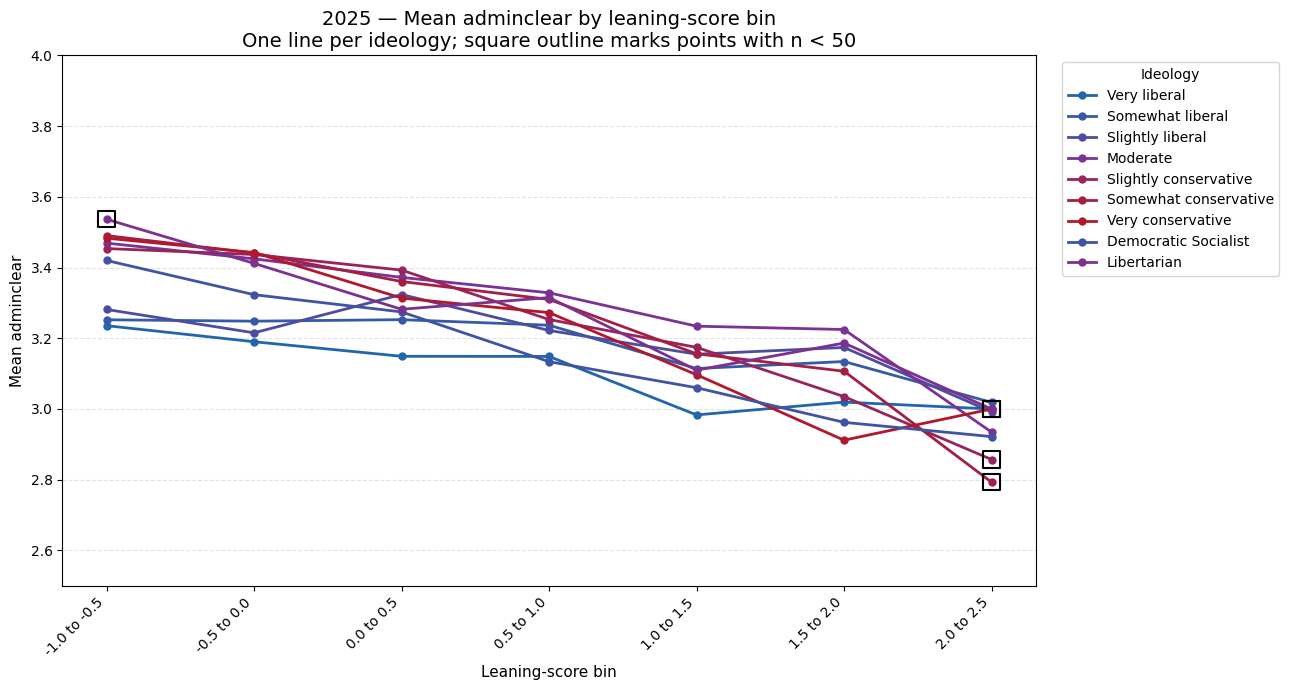

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# --- Settings ---
INPUT_CSV      = "cfsrALL.csv"
SCHOOL_COL     = "schoolname"
IDEO_COL       = "ideo"
DATAYEAR_COL   = "datayear"
ADMINCLEAR_COL = "adminclear"

TARGET_YEAR = 2025
LOW_N_THRESHOLD = 50

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Leaning-score bins
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0

ADMINCLEAR_ORDER = [1, 2, 3, 4, 5]

IDEO_ORDER = [1, 2, 3, 4, 5, 6, 7, 8, 9]
IDEO_LABELS = {
    1: "Very liberal",
    2: "Somewhat liberal",
    3: "Slightly liberal",
    4: "Moderate",
    5: "Slightly conservative",
    6: "Somewhat conservative",
    7: "Very conservative",
    8: "Democratic Socialist",
    9: "Libertarian",
}

# Blue -> purple -> red ideology gradient
IDEO_CMAP = LinearSegmentedColormap.from_list(
    "ideo_gradient",
    ["#2166ac", "#7b3294", "#b2182b"]
)


def ideology_color(ide_code):
    """
    Map ideology to gradient color:
    liberal -> blue, moderate/libertarian -> purple, conservative -> red
    """
    ideology_position = {
        1: 0.00,  # very liberal
        2: 0.12,
        3: 0.24,
        8: 0.18,  # democratic socialist, liberal side
        4: 0.50,  # moderate
        9: 0.52,  # libertarian near middle
        5: 0.76,
        6: 0.88,
        7: 1.00,  # very conservative
    }
    return IDEO_CMAP(ideology_position.get(ide_code, 0.5))


def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def _compute_school_leaning_scores(df):
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1–9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)

    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")
    return leaning_score.reset_index()


def _build_bin_metadata():
    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [
        f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}"
        for i in range(len(bin_edges) - 1)
    ]
    bin_centers = [
        (bin_edges[i] + bin_edges[i + 1]) / 2.0
        for i in range(len(bin_edges) - 1)
    ]
    bin_center_map = dict(zip(bin_labels, bin_centers))
    return bin_edges, bin_labels, bin_center_map


def _summarize_mean_adminclear(df_subset, used_bin_labels):
    rows = []

    for ide in IDEO_ORDER:
        for bin_label in used_bin_labels:
            mask = (
                (df_subset[IDEO_COL] == ide) &
                (df_subset["leaning_bin"] == bin_label) &
                (df_subset[ADMINCLEAR_COL].isin(ADMINCLEAR_ORDER))
            )

            n_people = int(mask.sum())
            mean_adminclear = df_subset.loc[mask, ADMINCLEAR_COL].mean() if n_people > 0 else np.nan

            rows.append({
                "ideology_code": ide,
                "ideology_label": IDEO_LABELS.get(ide, str(ide)),
                "leaning_bin": bin_label,
                "n_people": n_people,
                "mean_adminclear": mean_adminclear,
            })

    return pd.DataFrame(rows)


def make_adminclear_by_leaning_lines(df_all, year=2025):
    df = df_all.copy()
    df.columns = [c.strip() for c in df.columns]

    _require_cols(df, [SCHOOL_COL, IDEO_COL, DATAYEAR_COL, ADMINCLEAR_COL])

    for col in [IDEO_COL, DATAYEAR_COL, ADMINCLEAR_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df[DATAYEAR_COL] == year].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {year}.")

    leanings = _compute_school_leaning_scores(df)

    df_lean = df.merge(leanings, on=SCHOOL_COL, how="left")
    df_lean = df_lean[df_lean["leaning_score"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No respondents with a computed leaning_score after merging.")

    df_lean = df_lean[
        df_lean[IDEO_COL].isin(IDEO_ORDER) &
        df_lean[ADMINCLEAR_COL].isin(ADMINCLEAR_ORDER)
    ].copy()
    if df_lean.empty:
        raise ValueError("No valid rows after filtering ideology and adminclear.")

    bin_edges, all_bin_labels, _ = _build_bin_metadata()

    df_lean["leaning_bin"] = pd.cut(
        df_lean["leaning_score"],
        bins=bin_edges,
        labels=all_bin_labels,
        include_lowest=True,
        right=True,
    )

    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No rows fall into the defined leaning bins.")

    bin_counts = df_lean["leaning_bin"].value_counts().reindex(all_bin_labels)
    used_bin_labels = [b for b in all_bin_labels if bin_counts.get(b, 0) > 0]
    if not used_bin_labels:
        raise ValueError("No leaning-score bins have any data.")

    summary = _summarize_mean_adminclear(df_lean, used_bin_labels)

    x_positions = np.arange(len(used_bin_labels))
    x_map = {b: i for i, b in enumerate(used_bin_labels)}

    fig_width = max(13, 1.0 * len(used_bin_labels))
    fig, ax = plt.subplots(figsize=(fig_width, 7))

    for ide in IDEO_ORDER:
        ide_df = summary[summary["ideology_code"] == ide].copy()
        ide_df["x"] = ide_df["leaning_bin"].map(x_map)
        ide_df = ide_df.sort_values("x")

        x = ide_df["x"].to_numpy()
        y = ide_df["mean_adminclear"].to_numpy()
        n = ide_df["n_people"].to_numpy()
        color = ideology_color(ide)

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2.0,
            markersize=5,
            label=IDEO_LABELS[ide],
            color=color,
        )

        low_n_mask = (n > 0) & (n < LOW_N_THRESHOLD) & (~np.isnan(y))
        if low_n_mask.any():
            ax.scatter(
                x[low_n_mask],
                y[low_n_mask],
                marker="s",
                s=140,
                facecolors="none",
                edgecolors="black",
                linewidths=1.5,
                zorder=5,
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(used_bin_labels, rotation=45, ha="right")
    ax.set_ylim(2.5, 4.0)
    ax.set_ylabel("Mean adminclear", fontsize=11)
    ax.set_xlabel("Leaning-score bin", fontsize=11)
    ax.set_title(
        f"{year} — Mean adminclear by leaning-score bin\n"
        f"One line per ideology; square outline marks points with n < {LOW_N_THRESHOLD}",
        fontsize=14,
    )
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.legend(title="Ideology", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return summary


# --- Run ---
df_all = pd.read_csv(INPUT_CSV)
summary_df = make_adminclear_by_leaning_lines(df_all, year=TARGET_YEAR)

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_7869/2432073723.py:360: DtypeWarning: Columns (19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(INPUT_CSV)


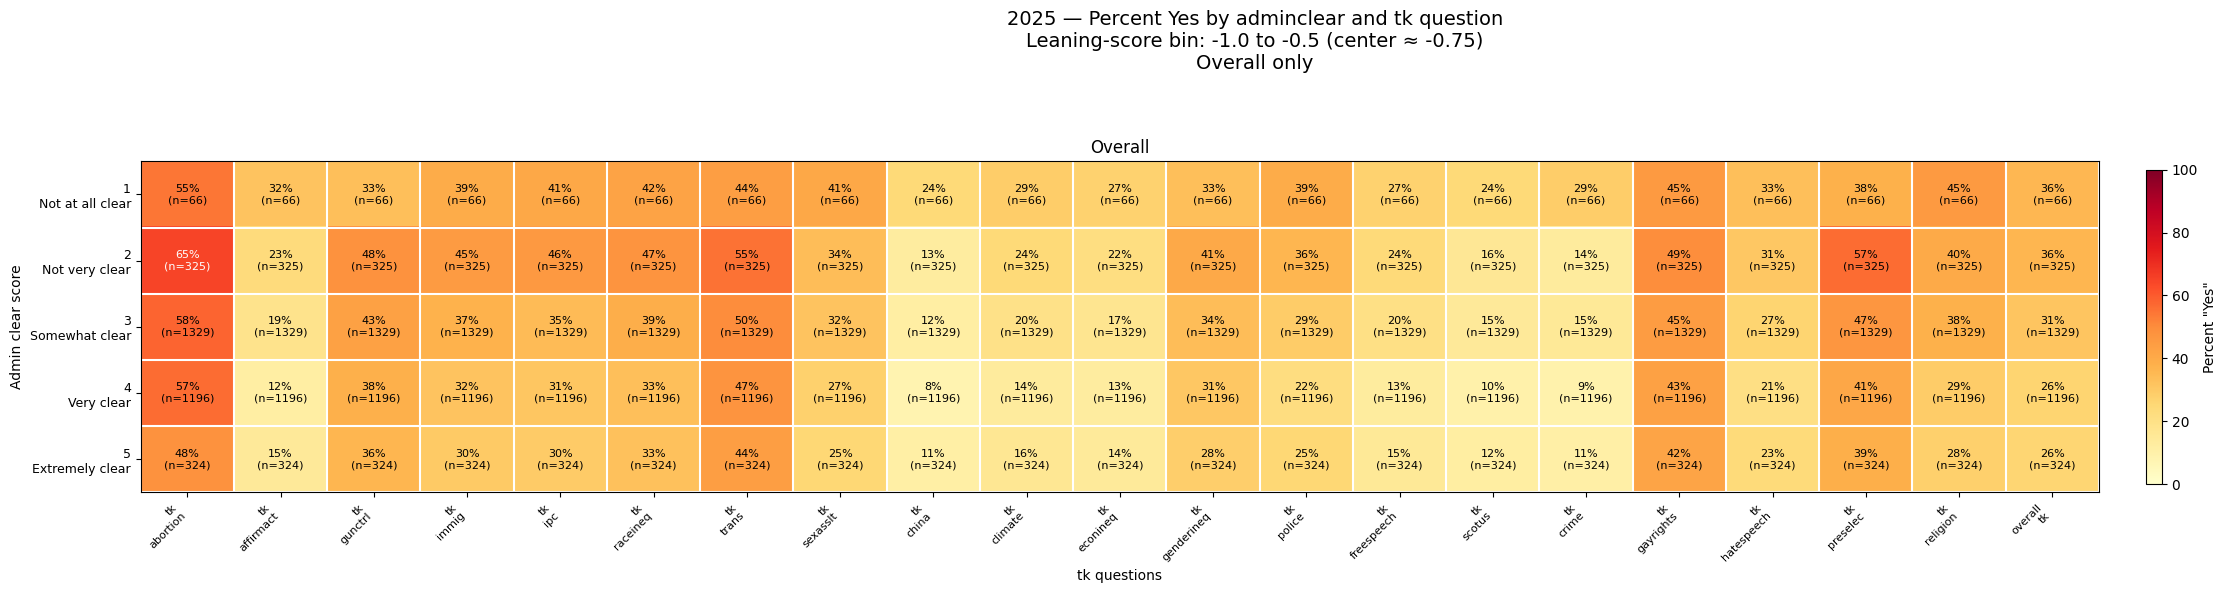

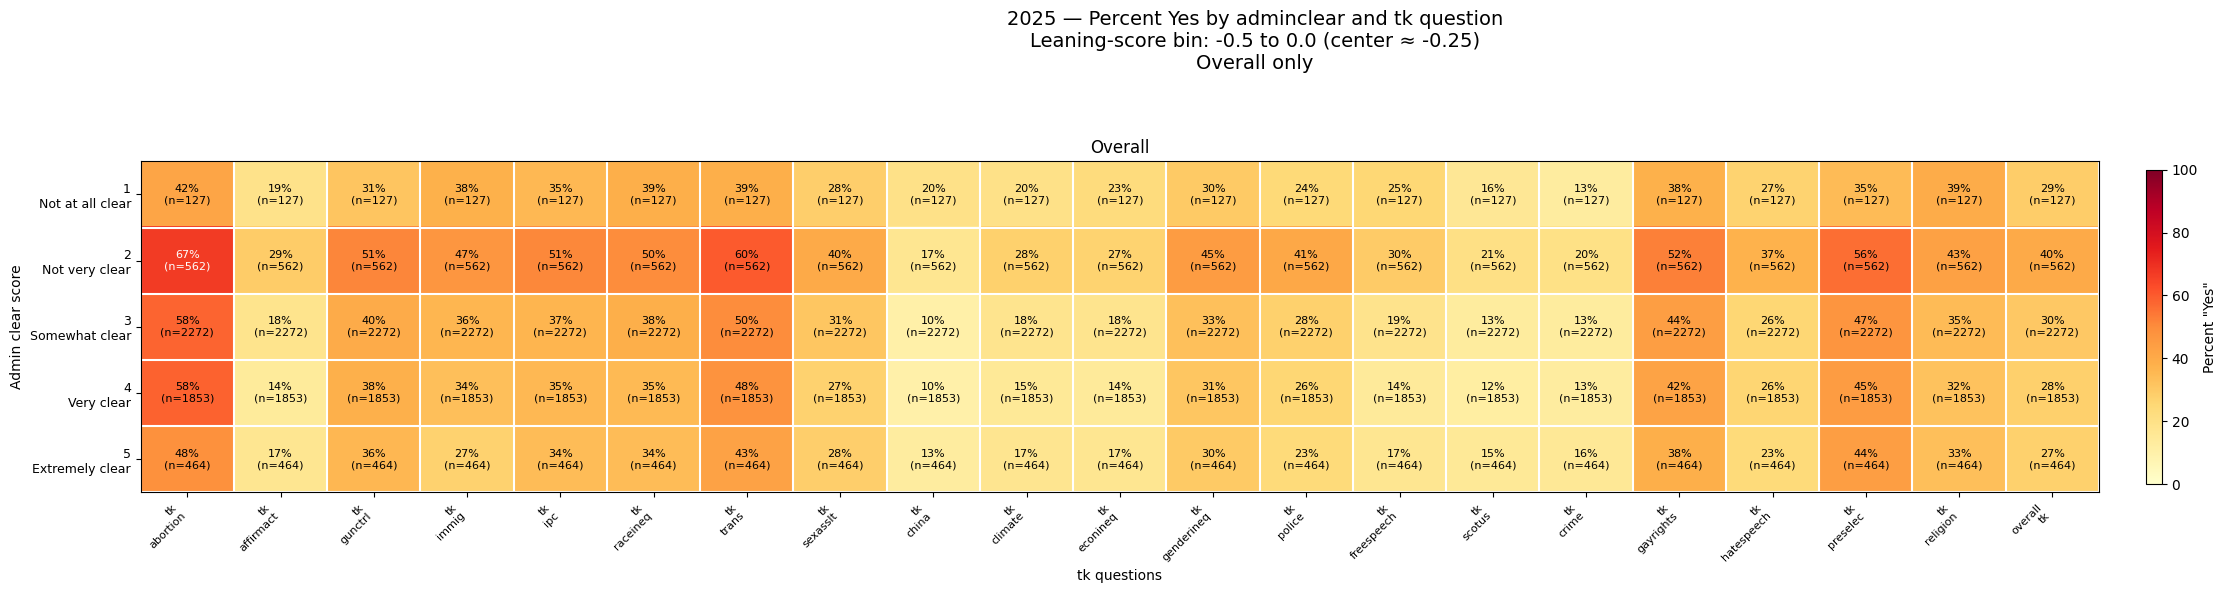

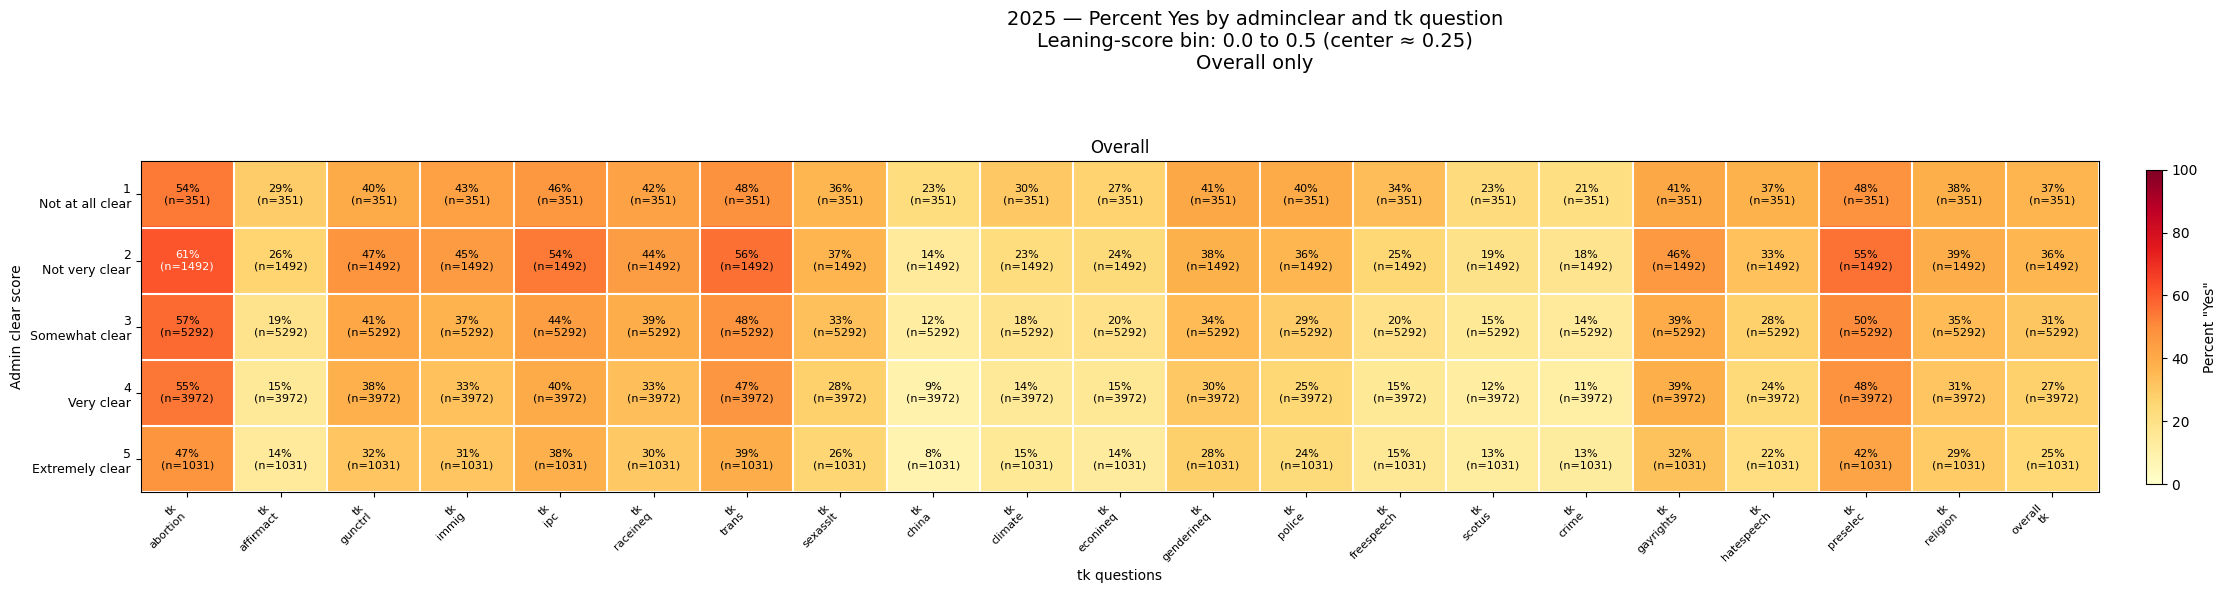

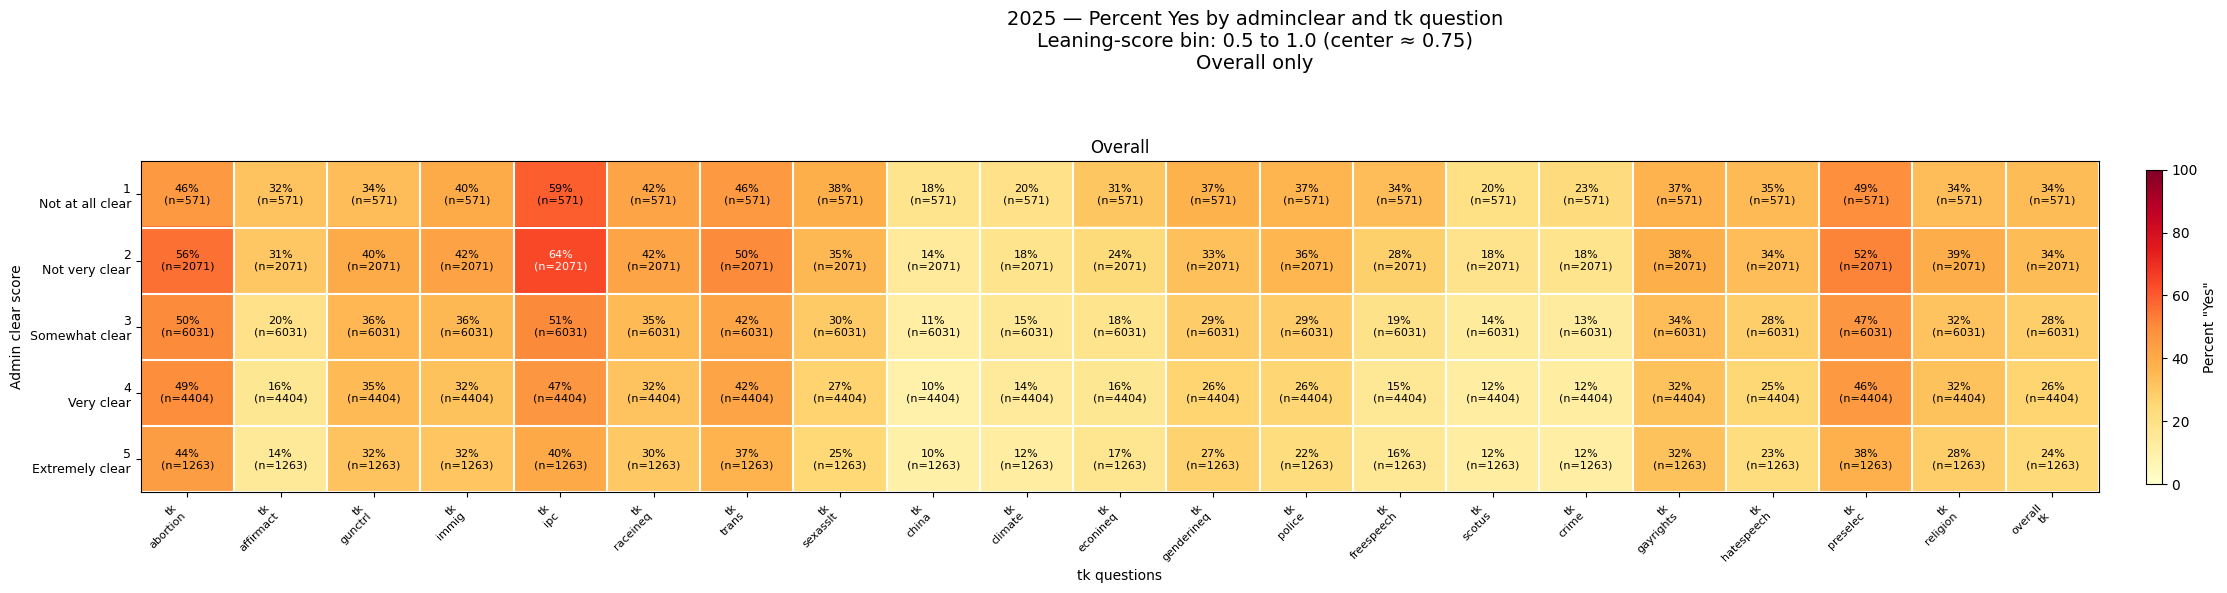

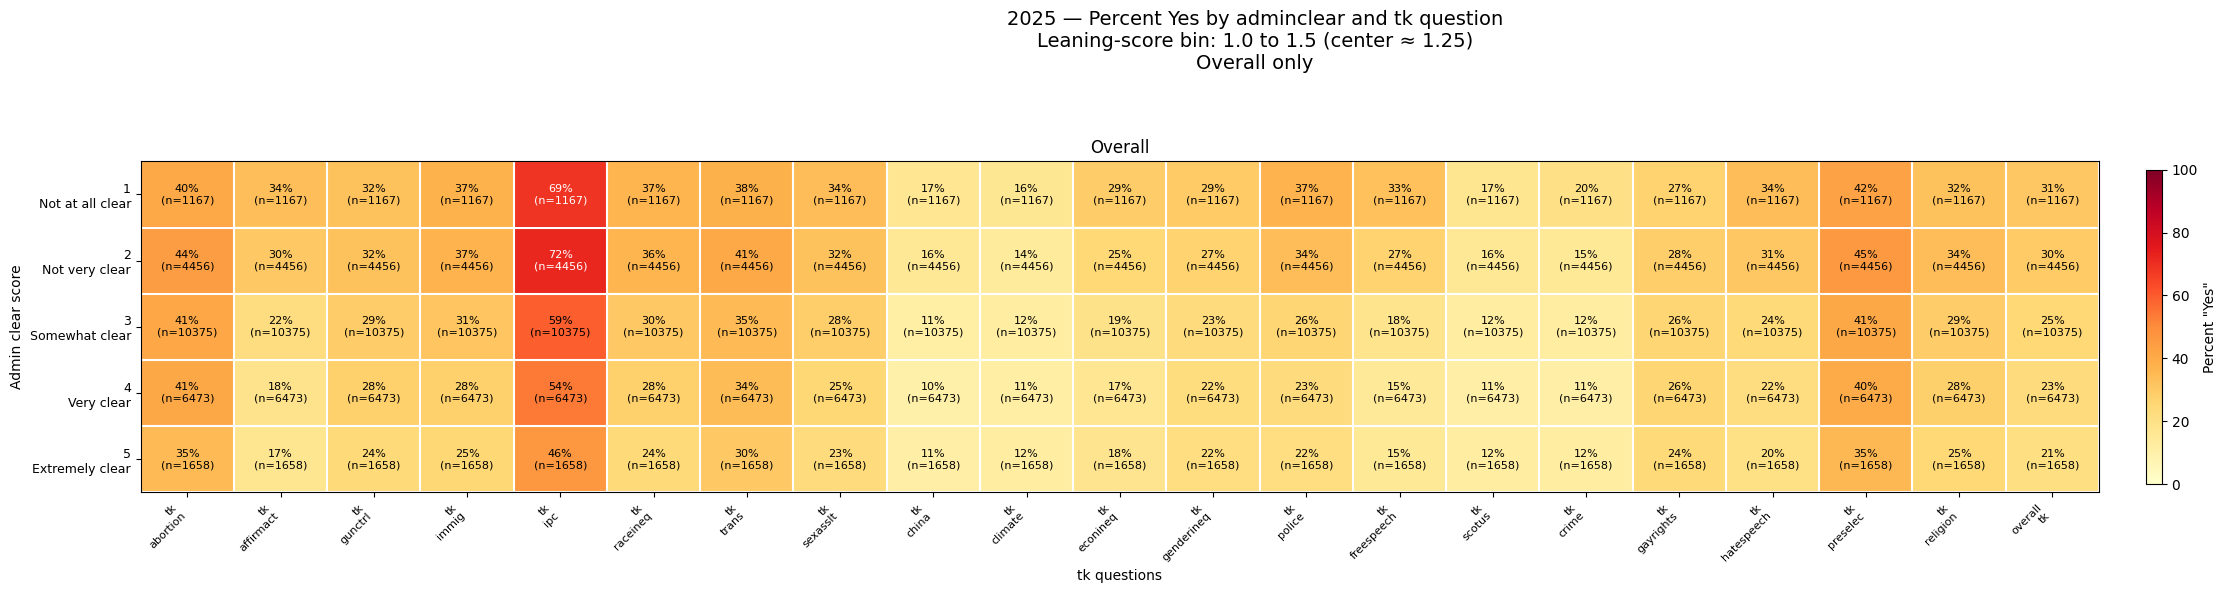

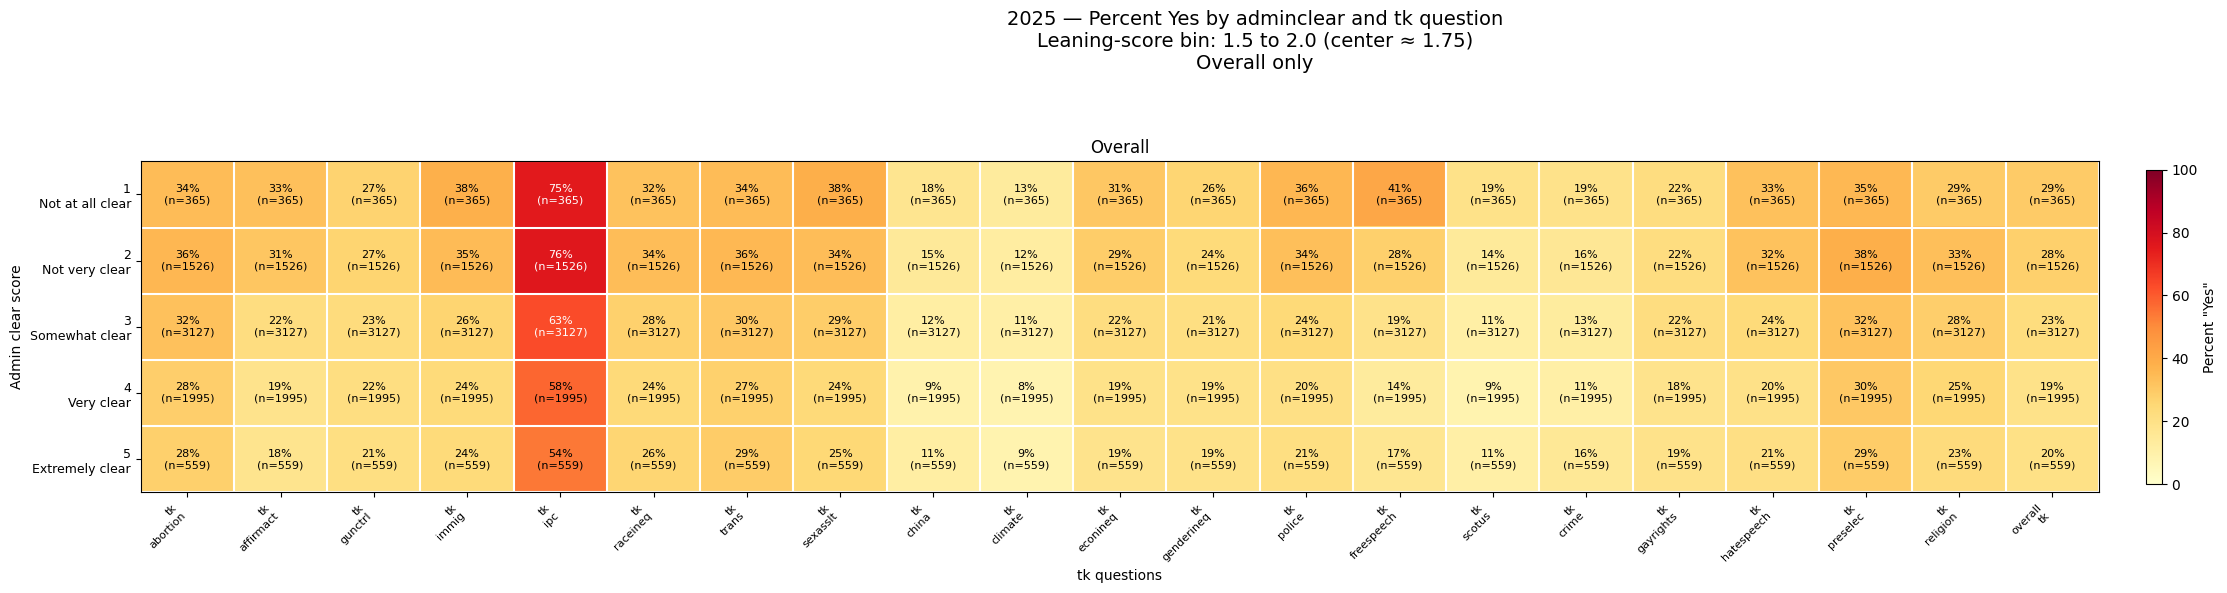

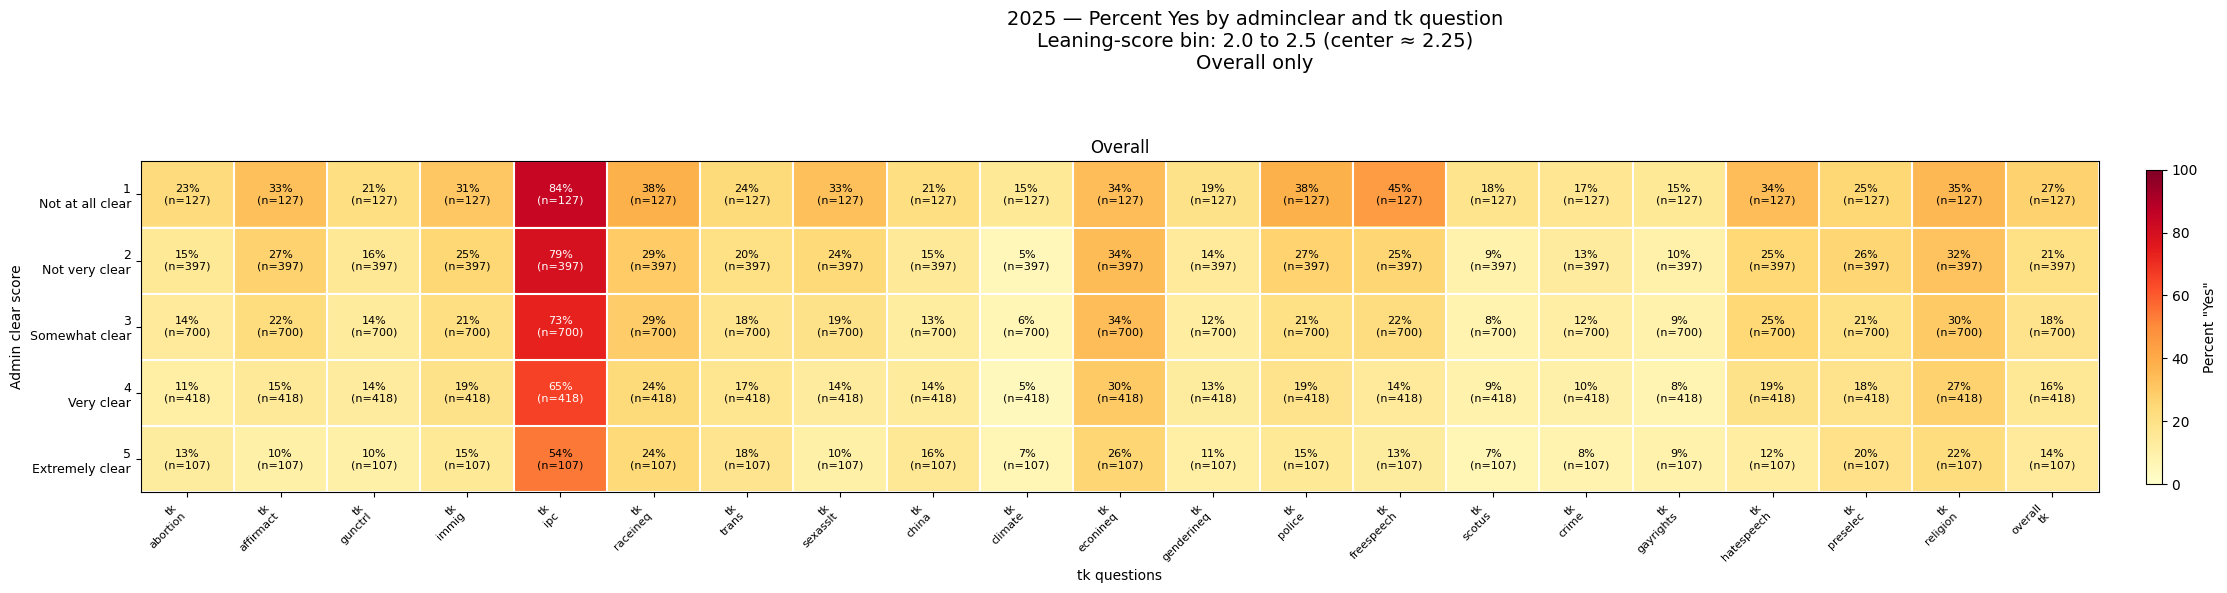

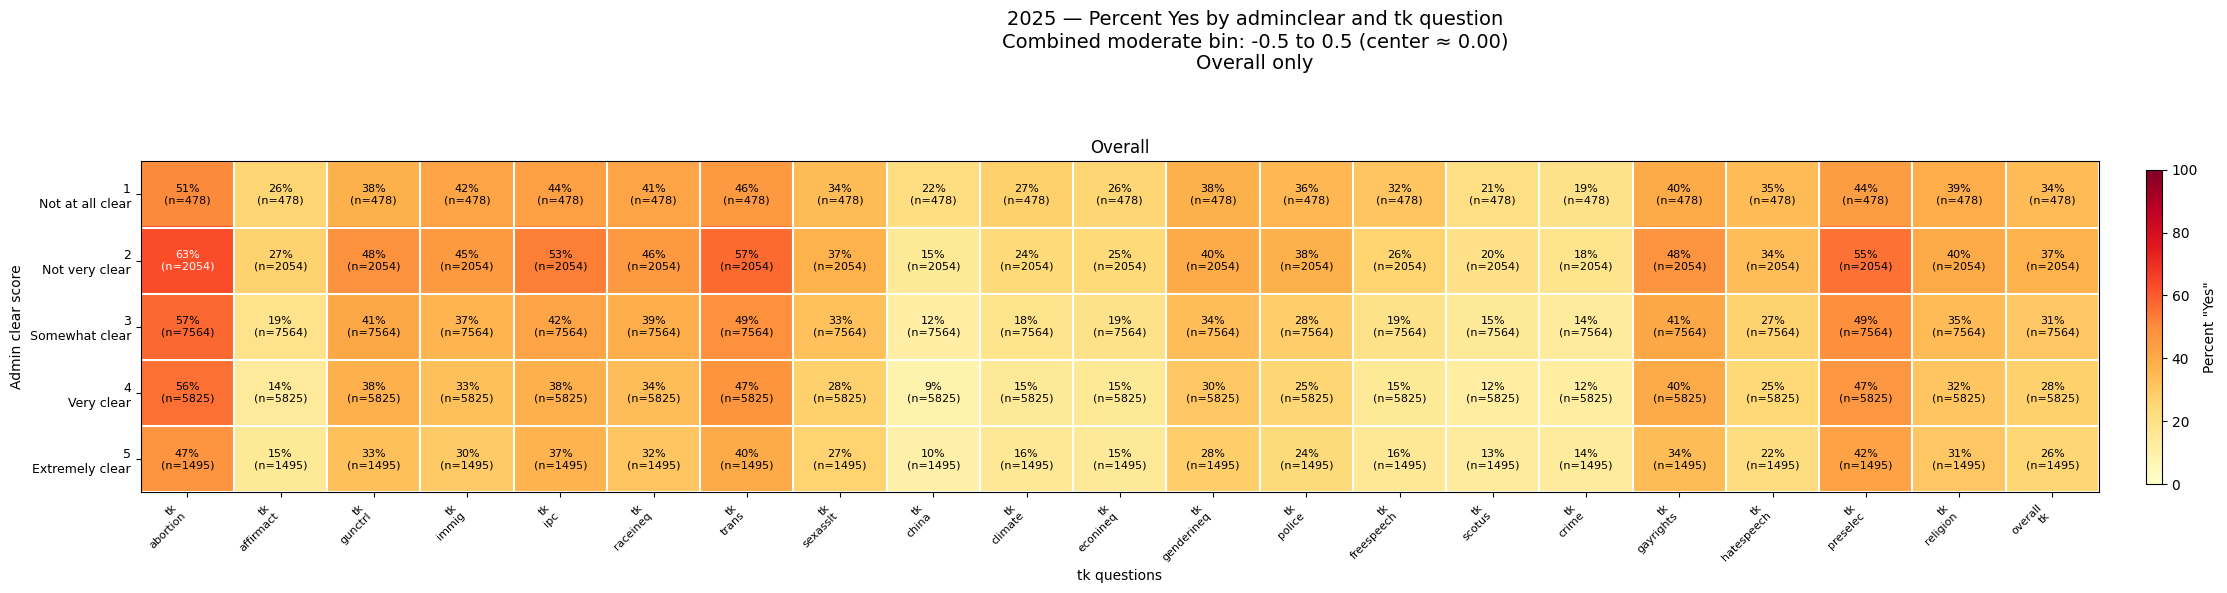

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Settings ---
INPUT_CSV      = "cfsrALL.csv"
SCHOOL_COL     = "schoolname"
IDEO_COL       = "ideo"
DATAYEAR_COL   = "datayear"
ADMINCLEAR_COL = "adminclear"

TARGET_YEAR = 2025
OVERALL_TK_COL = "overall_tk"
MODERATE_MIN = -0.5
MODERATE_MAX = 0.5

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Leaning-score bins
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0

ADMINCLEAR_ORDER = [1, 2, 3, 4, 5]
ADMINCLEAR_LABELS = {
    1: "1\nNot at all clear",
    2: "2\nNot very clear",
    3: "3\nSomewhat clear",
    4: "4\nVery clear",
    5: "5\nExtremely clear",
}


def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def _get_tk_cols_excluding(df_cols):
    """
    Return tk* columns excluding:
      - tk_none
      - tkpol* (case-insensitive)
    """
    tk_cols = []
    for col in df_cols:
        c = col.lower()
        if not c.startswith("tk"):
            continue
        if c == "tk_none":
            continue
        if c.startswith("tkpol"):
            continue
        tk_cols.append(col)
    return tk_cols


def _compute_school_leaning_scores(df):
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1–9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)

    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")
    return leaning_score.reset_index()


def _build_bin_metadata():
    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [
        f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}"
        for i in range(len(bin_edges) - 1)
    ]
    bin_centers = [
        (bin_edges[i] + bin_edges[i + 1]) / 2.0
        for i in range(len(bin_edges) - 1)
    ]
    bin_center_map = dict(zip(bin_labels, bin_centers))
    return bin_edges, bin_labels, bin_center_map


def _pretty_tk_label(col):
    return col.replace("_", "\n")


def _add_overall_tk_column(df, tk_cols):
    """
    Add overall_tk as the row-wise average of valid 0/1 tk responses,
    excluding tk_ipc.
    """
    source_cols = [c for c in tk_cols if c.lower() != "tk_ipc"]

    if not source_cols:
        df[OVERALL_TK_COL] = np.nan
        return df

    valid_vals = df[source_cols].where(df[source_cols].isin([0, 1]), np.nan)
    df[OVERALL_TK_COL] = valid_vals.mean(axis=1, skipna=True)
    return df


def _make_heatmap_matrices(df_subset, tk_cols):
    """
    Rows = adminclear 1..5
    Cols = tk questions + overall_tk
    Values = percent yes
    Labels = 'XX%\\n(n=N)'
    """
    n_rows = len(ADMINCLEAR_ORDER)
    n_cols = len(tk_cols)

    pct_mat = np.full((n_rows, n_cols), np.nan, dtype=float)
    n_mat = np.zeros((n_rows, n_cols), dtype=int)
    label_mat = np.empty((n_rows, n_cols), dtype=object)

    for i, admin_val in enumerate(ADMINCLEAR_ORDER):
        for j, tk_col in enumerate(tk_cols):
            if tk_col == OVERALL_TK_COL:
                mask = (
                    (df_subset[ADMINCLEAR_COL] == admin_val) &
                    (df_subset[OVERALL_TK_COL].notna())
                )

                n_valid = int(mask.sum())
                n_mat[i, j] = n_valid

                if n_valid > 0:
                    pct_yes = 100.0 * df_subset.loc[mask, OVERALL_TK_COL].mean()
                    pct_mat[i, j] = pct_yes
                    label_mat[i, j] = f"{pct_yes:.0f}%\n(n={n_valid})"
                else:
                    label_mat[i, j] = ""
            else:
                mask = (
                    (df_subset[ADMINCLEAR_COL] == admin_val) &
                    (df_subset[tk_col].isin([0, 1]))
                )

                n_valid = int(mask.sum())
                n_yes = int((df_subset.loc[mask, tk_col] == 1).sum())

                n_mat[i, j] = n_valid

                if n_valid > 0:
                    pct_yes = 100.0 * n_yes / n_valid
                    pct_mat[i, j] = pct_yes
                    label_mat[i, j] = f"{pct_yes:.0f}%\n(n={n_valid})"
                else:
                    label_mat[i, j] = ""

    return pct_mat, n_mat, label_mat


def _draw_single_heatmap(ax, pct_mat, label_mat, tk_cols, title):
    masked = np.ma.masked_invalid(pct_mat)
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color="#f3f4f6")

    im = ax.imshow(masked, aspect="auto", vmin=0, vmax=100, cmap=cmap)

    ax.set_title(title, fontsize=12)
    ax.set_xticks(range(len(tk_cols)))
    ax.set_xticklabels(
        [_pretty_tk_label(c) for c in tk_cols],
        fontsize=8,
        rotation=45,
        ha="right"
    )
    ax.set_yticks(range(len(ADMINCLEAR_ORDER)))
    ax.set_yticklabels([ADMINCLEAR_LABELS[i] for i in ADMINCLEAR_ORDER], fontsize=9)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, len(tk_cols), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ADMINCLEAR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Cell labels
    for i in range(label_mat.shape[0]):
        for j in range(label_mat.shape[1]):
            if label_mat[i, j]:
                val = pct_mat[i, j]
                text_color = "black" if pd.isna(val) or val < 60 else "white"
                ax.text(
                    j, i, label_mat[i, j],
                    ha="center", va="center",
                    fontsize=8, color=text_color
                )

    return im


def _plot_bin_heatmap(df_bin, tk_cols, bin_label, bin_center, year, subtitle_prefix="Leaning-score bin"):
    pct_mat, n_mat, label_mat = _make_heatmap_matrices(df_bin, tk_cols)

    fig_width = max(10, 1.2 * len(tk_cols))
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    im = _draw_single_heatmap(
        ax=ax,
        pct_mat=pct_mat,
        label_mat=label_mat,
        tk_cols=tk_cols,
        title="Overall"
    )

    ax.set_xlabel("tk questions", fontsize=10)
    ax.set_ylabel("Admin clear score", fontsize=10)

    fig.suptitle(
        f"{year} — Percent Yes by adminclear and tk question\n"
        f"{subtitle_prefix}: {bin_label} (center ≈ {bin_center:.2f})\n"
        f"Overall only",
        fontsize=14
    )

    cbar = fig.colorbar(im, ax=ax, shrink=0.95, pad=0.02)
    cbar.set_label('Percent "Yes"', fontsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()
    plt.close(fig)


def generate_adminclear_tk_heatmaps(df_all, year=2025):
    df = df_all.copy()
    df.columns = [c.strip() for c in df.columns]

    _require_cols(df, [SCHOOL_COL, IDEO_COL, DATAYEAR_COL, ADMINCLEAR_COL])

    # Numeric coercion
    for col in [IDEO_COL, DATAYEAR_COL, ADMINCLEAR_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Filter year
    df = df[df[DATAYEAR_COL] == year].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {year}.")

    # Compute school leaning scores
    leanings = _compute_school_leaning_scores(df)

    # Merge back
    df_lean = df.merge(leanings, on=SCHOOL_COL, how="left")
    df_lean = df_lean[df_lean["leaning_score"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No respondents with a computed leaning_score after merging.")

    # Keep only useful adminclear rows
    df_lean = df_lean[df_lean[ADMINCLEAR_COL].isin(ADMINCLEAR_ORDER)].copy()
    if df_lean.empty:
        raise ValueError("No valid rows after filtering adminclear to 1–5.")

    # Find tk columns
    tk_cols = _get_tk_cols_excluding(df_lean.columns)
    if not tk_cols:
        raise ValueError("No tk* columns found after excluding tk_none and tkpol*.")

    # Coerce tk columns to numeric
    df_lean[tk_cols] = df_lean[tk_cols].apply(pd.to_numeric, errors="coerce")

    # Keep only tk columns with at least one valid 0/1 response
    tk_cols_used = [col for col in tk_cols if df_lean[col].isin([0, 1]).sum() > 0]
    if not tk_cols_used:
        raise ValueError("No tk* columns have any valid 0/1 responses in this year.")

    # Add overall_tk as row-wise average of all valid tk questions except tk_ipc
    df_lean = _add_overall_tk_column(df_lean, tk_cols_used)

    tk_cols_plot = tk_cols_used.copy()
    if df_lean[OVERALL_TK_COL].notna().sum() > 0:
        tk_cols_plot.append(OVERALL_TK_COL)

    # Build bins
    bin_edges, bin_labels, bin_center_map = _build_bin_metadata()

    df_lean["leaning_bin"] = pd.cut(
        df_lean["leaning_score"],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
        right=True,
    )

    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No rows fall into the defined leaning bins.")

    # Plot one heatmap per leaning bin
    for bin_label in df_lean["leaning_bin"].cat.categories.tolist():
        df_bin = df_lean[df_lean["leaning_bin"] == bin_label].copy()
        if df_bin.empty:
            continue

        tk_cols_bin = [
            col for col in tk_cols_plot
            if (
                df_bin[col].notna().sum() > 0
                if col == OVERALL_TK_COL
                else df_bin[col].isin([0, 1]).sum() > 0
            )
        ]
        if not tk_cols_bin:
            continue

        _plot_bin_heatmap(
            df_bin=df_bin,
            tk_cols=tk_cols_bin,
            bin_label=bin_label,
            bin_center=bin_center_map[bin_label],
            year=year
        )

    # Extra combined moderate plot at the end: -0.5 to 0.5
    df_moderate = df_lean[
        df_lean["leaning_score"].between(MODERATE_MIN, MODERATE_MAX, inclusive="both")
    ].copy()

    if not df_moderate.empty:
        tk_cols_moderate = [
            col for col in tk_cols_plot
            if (
                df_moderate[col].notna().sum() > 0
                if col == OVERALL_TK_COL
                else df_moderate[col].isin([0, 1]).sum() > 0
            )
        ]

        if tk_cols_moderate:
            _plot_bin_heatmap(
                df_bin=df_moderate,
                tk_cols=tk_cols_moderate,
                bin_label=f"{MODERATE_MIN:.1f} to {MODERATE_MAX:.1f}",
                bin_center=0.0,
                year=year,
                subtitle_prefix="Combined moderate bin"
            )


# --- Run ---
df_all = pd.read_csv(INPUT_CSV)
generate_adminclear_tk_heatmaps(df_all, year=TARGET_YEAR)

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Widget bits (Jupyter)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False


# --- Settings ---
INPUT_CSV      = "cfsrALL.csv"
SCHOOL_COL     = "schoolname"
IDEO_COL       = "ideo"
GENDER_COL     = "gender_bin"   # 1 = Men, 2 = Women
DATAYEAR_COL   = "datayear"
ADMINCLEAR_COL = "adminclear"
TK_IPC_COL     = "tk_ipc"
RELIGION_COL   = "religion"

# Exact Ivy names as they appear in cfsrALL.csv
IVY_SCHOOLS = [
    "Brown University",
    "Columbia University in the City of New York",
    "Cornell University",
    "Dartmouth College",
    "Harvard University",
    "Princeton University",
    "University of Pennsylvania",
    "Yale University",
]

# Religion groups
VALID_RELIGION_CODES = list(range(1, 14))
JEWISH_CODES = [5]
CHRISTIAN_CODES = [1, 2, 3, 4, 10]   # Protestant, Catholic, Mormon, Orthodox, Christian
JEWISH_AND_CHRISTIAN_CODES = sorted(set(JEWISH_CODES + CHRISTIAN_CODES))
OTHER_RELIGION_CODES = [c for c in VALID_RELIGION_CODES if c not in JEWISH_AND_CHRISTIAN_CODES]

# Ideology subgroup
LIBERAL_CODES = [1, 2, 3]  # Very liberal, somewhat liberal, slightly liberal

# Leaning-score weights
WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}

# Leaning-score bins
BIN_WIDTH = 0.5
MIN_SCORE = -3.0
MAX_SCORE = 3.0

ADMINCLEAR_ORDER = [1, 2, 3, 4, 5]
ADMINCLEAR_LABELS = {
    1: "1\nNot at all clear",
    2: "2\nNot very clear",
    3: "3\nSomewhat clear",
    4: "4\nVery clear",
    5: "5\nExtremely clear",
}

GROUPS = [
    ("Overall", None),
    ("Men", 1),
    ("Women", 2),
]

ADJ_CONT_COL = "__adminclear_school_adjusted"
ADJ_CAT_COL  = "__adminclear_school_adjusted_cat"


def _require_cols(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")


def _compute_school_leaning_scores(df):
    valid_mask = df[IDEO_COL].between(1, 9, inclusive="both")
    df_valid = df.loc[valid_mask, [SCHOOL_COL, IDEO_COL]].copy()

    if df_valid.empty:
        raise ValueError("No valid ideology responses (1–9) in selected year.")

    df_valid["weight"] = df_valid[IDEO_COL].map(WEIGHTS).fillna(0)

    grp = df_valid.groupby(SCHOOL_COL, dropna=True)
    numerator = grp["weight"].sum()
    denominator = grp[IDEO_COL].size()

    leaning_score = (numerator / denominator).rename("leaning_score")
    return leaning_score.reset_index()


def _build_bin_metadata():
    bin_edges = np.arange(MIN_SCORE, MAX_SCORE + BIN_WIDTH, BIN_WIDTH)
    bin_labels = [
        f"{bin_edges[i]:.1f} to {bin_edges[i + 1]:.1f}"
        for i in range(len(bin_edges) - 1)
    ]
    bin_centers = [
        (bin_edges[i] + bin_edges[i + 1]) / 2.0
        for i in range(len(bin_edges) - 1)
    ]
    bin_center_map = dict(zip(bin_labels, bin_centers))
    return bin_edges, bin_labels, bin_center_map


def _print_school_counts_by_bin(leanings_binned, used_bin_labels):
    school_bin = leanings_binned[[SCHOOL_COL, "leaning_bin"]].drop_duplicates().copy()
    counts = school_bin["leaning_bin"].value_counts().reindex(used_bin_labels, fill_value=0)

    print("Unique schools by leaning-score bin:")
    for bin_label in used_bin_labels:
        print(f"  {bin_label}: {int(counts[bin_label])} schools")
    print()


def _make_heatmap_matrices(df_subset, bin_labels, adminclear_cat_col):
    n_rows = len(ADMINCLEAR_ORDER)
    n_cols = len(bin_labels)

    pct_mat = np.full((n_rows, n_cols), np.nan, dtype=float)
    n_mat = np.zeros((n_rows, n_cols), dtype=int)
    label_mat = np.empty((n_rows, n_cols), dtype=object)

    for i, admin_val in enumerate(ADMINCLEAR_ORDER):
        for j, bin_label in enumerate(bin_labels):
            mask = (
                (df_subset["leaning_bin"] == bin_label) &
                (df_subset[adminclear_cat_col] == admin_val) &
                (df_subset[TK_IPC_COL].isin([0, 1]))
            )

            n_valid = int(mask.sum())
            n_difficult = int((df_subset.loc[mask, TK_IPC_COL] == 1).sum())

            n_mat[i, j] = n_valid

            if n_valid > 0:
                pct_difficult = 100.0 * n_difficult / n_valid
                pct_mat[i, j] = pct_difficult
                label_mat[i, j] = f"{pct_difficult:.0f}%\n(n={n_valid})"
            else:
                label_mat[i, j] = ""

    return pct_mat, n_mat, label_mat


def _compute_mean_by_bin(df_subset, bin_labels, value_col):
    means = []
    for bin_label in bin_labels:
        mask = (
            (df_subset["leaning_bin"] == bin_label) &
            (df_subset[value_col].notna())
        )
        if mask.sum() > 0:
            means.append(df_subset.loc[mask, value_col].mean())
        else:
            means.append(np.nan)
    return np.array(means, dtype=float)


def _draw_heatmap_with_adminclear_marker(ax, pct_mat, label_mat, bin_labels, mean_adminclear, panel_title):
    masked = np.ma.masked_invalid(pct_mat)
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color="#f3f4f6")

    im = ax.imshow(masked, aspect="auto", vmin=0, vmax=100, cmap=cmap, origin="upper")

    ax.set_title(panel_title, fontsize=12)
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(ADMINCLEAR_ORDER)))
    ax.set_yticklabels([ADMINCLEAR_LABELS[i] for i in ADMINCLEAR_ORDER], fontsize=9)

    ax.set_xticks(np.arange(-0.5, len(bin_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ADMINCLEAR_ORDER), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(label_mat.shape[0]):
        for j in range(label_mat.shape[1]):
            if label_mat[i, j]:
                val = pct_mat[i, j]
                text_color = "black" if pd.isna(val) or val < 60 else "white"
                ax.text(
                    j, i,
                    label_mat[i, j],
                    ha="center",
                    va="center",
                    fontsize=8,
                    color=text_color,
                )

    x = np.arange(len(bin_labels))
    y = mean_adminclear - 1.0

    valid = ~np.isnan(y)
    if valid.any():
        ax.plot(
            x[valid],
            y[valid],
            marker="o",
            linewidth=2,
            markersize=7,
            color="black",
        )
        for xv, yv, mean_val in zip(x[valid], y[valid], mean_adminclear[valid]):
            ax.text(
                xv,
                yv - 0.18,
                f"{mean_val:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                color="black",
                bbox=dict(
                    boxstyle="round,pad=0.15",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.8,
                ),
            )

    return im


def _add_school_adjusted_adminclear(df_subset):
    df_adj = df_subset.copy()

    school_mean = df_adj.groupby(SCHOOL_COL)[ADMINCLEAR_COL].transform("mean")
    bin_grand_mean = df_adj.groupby("leaning_bin", observed=False)[ADMINCLEAR_COL].transform("mean")

    df_adj[ADJ_CONT_COL] = df_adj[ADMINCLEAR_COL] - school_mean + bin_grand_mean
    df_adj[ADJ_CAT_COL] = df_adj[ADJ_CONT_COL].round().clip(1, 5).astype(int)

    return df_adj


def _plot_single_heatmap_figure(
    df_group,
    used_bin_labels,
    year,
    group_name,
    fig_width,
    adminclear_cat_col,
    mean_col,
    title_prefix,
    title_note
):
    if df_group.empty:
        print(f"No rows found for {group_name}.")
        return

    pct_mat, _, label_mat = _make_heatmap_matrices(
        df_group,
        used_bin_labels,
        adminclear_cat_col=adminclear_cat_col
    )
    mean_adminclear = _compute_mean_by_bin(
        df_group,
        used_bin_labels,
        value_col=mean_col
    )

    fig, ax = plt.subplots(figsize=(fig_width, 6.5))

    im = _draw_heatmap_with_adminclear_marker(
        ax=ax,
        pct_mat=pct_mat,
        label_mat=label_mat,
        bin_labels=used_bin_labels,
        mean_adminclear=mean_adminclear,
        panel_title=group_name,
    )

    ax.set_xlabel("Leaning-score bin", fontsize=11)
    ax.set_ylabel("Admin clear score", fontsize=11)
    ax.set_title(
        f"{year} — {group_name}: {title_prefix}\n{title_note}",
        fontsize=14,
    )

    cbar = fig.colorbar(im, ax=ax, shrink=0.95, pad=0.02)
    cbar.set_label('Percent "difficult" on tk_ipc', fontsize=10)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def _print_ivy_bin_assignments(df_lean, bin_center_map):
    ivy_df = (
        df_lean[[SCHOOL_COL, "leaning_score", "leaning_bin"]]
        .drop_duplicates()
        .copy()
    )
    ivy_df = ivy_df[ivy_df[SCHOOL_COL].isin(IVY_SCHOOLS)].copy()

    if ivy_df.empty:
        print("No Ivy League schools found in the filtered data.")
        print()
        return

    ivy_df["bin_center"] = ivy_df["leaning_bin"].map(bin_center_map)
    ivy_df = ivy_df.sort_values(["bin_center", "leaning_score", SCHOOL_COL], ascending=[True, False, True])

    print("Ivy League schools by leaning-score bin:")
    for bin_label in ivy_df["leaning_bin"].dropna().unique():
        sub = ivy_df[ivy_df["leaning_bin"] == bin_label].sort_values("leaning_score", ascending=False)
        print(f"\n{bin_label}:")
        for _, row in sub.iterrows():
            print(f"  {row[SCHOOL_COL]} (leaning_score={row['leaning_score']:.3f})")
    print()


def _plot_religion_subset_figures(df_lean, used_bin_labels, year, fig_width):
    religion_plots = [
        ("Jewish students only", JEWISH_CODES),
        ("Jewish + any shade of Christian", JEWISH_AND_CHRISTIAN_CODES),
        ("Others", OTHER_RELIGION_CODES),
    ]

    for plot_name, codes in religion_plots:
        df_group = df_lean[
            df_lean[RELIGION_COL].isin(codes) &
            df_lean[RELIGION_COL].isin(VALID_RELIGION_CODES)
        ].copy()

        if df_group.empty:
            print(f"No rows found for {plot_name}.")
            continue

        bin_counts = df_group["leaning_bin"].value_counts().reindex(used_bin_labels, fill_value=0)
        group_used_bins = [b for b in used_bin_labels if bin_counts.get(b, 0) > 0]

        if not group_used_bins:
            print(f"No leaning-bin rows found for {plot_name}.")
            continue

        _plot_single_heatmap_figure(
            df_group=df_group,
            used_bin_labels=group_used_bins,
            year=year,
            group_name=plot_name,
            fig_width=fig_width,
            adminclear_cat_col=ADMINCLEAR_COL,
            mean_col=ADMINCLEAR_COL,
            title_prefix="tk_ipc percent difficult by leaning-score bin and adminclear",
            title_note="Black marker/line = mean adminclear within each leaning-score bin",
        )


def _plot_ideology_subset_figures(df_lean, used_bin_labels, year, fig_width):
    ideology_plots = [
        ("Any shade of liberal students", LIBERAL_CODES),
    ]

    for plot_name, codes in ideology_plots:
        df_group = df_lean[df_lean[IDEO_COL].isin(codes)].copy()

        if df_group.empty:
            print(f"No rows found for {plot_name}.")
            continue

        bin_counts = df_group["leaning_bin"].value_counts().reindex(used_bin_labels, fill_value=0)
        group_used_bins = [b for b in used_bin_labels if bin_counts.get(b, 0) > 0]

        if not group_used_bins:
            print(f"No leaning-bin rows found for {plot_name}.")
            continue

        _plot_single_heatmap_figure(
            df_group=df_group,
            used_bin_labels=group_used_bins,
            year=year,
            group_name=plot_name,
            fig_width=fig_width,
            adminclear_cat_col=ADMINCLEAR_COL,
            mean_col=ADMINCLEAR_COL,
            title_prefix="tk_ipc percent difficult by leaning-score bin and adminclear",
            title_note="Black marker/line = mean adminclear within each leaning-score bin",
        )


def make_adminclear_by_leaning_heatmaps(df_all, year):
    df = df_all.copy()
    df.columns = [c.strip() for c in df.columns]

    _require_cols(
        df,
        [SCHOOL_COL, IDEO_COL, GENDER_COL, DATAYEAR_COL, ADMINCLEAR_COL, TK_IPC_COL, RELIGION_COL]
    )

    for col in [IDEO_COL, GENDER_COL, DATAYEAR_COL, ADMINCLEAR_COL, TK_IPC_COL, RELIGION_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df[SCHOOL_COL] = df[SCHOOL_COL].astype(str).str.strip()

    df = df[df[DATAYEAR_COL] == year].copy()
    if df.empty:
        raise ValueError(f"No rows found for datayear {year}.")

    leanings = _compute_school_leaning_scores(df)
    leanings[SCHOOL_COL] = leanings[SCHOOL_COL].astype(str).str.strip()

    df_lean = df.merge(leanings, on=SCHOOL_COL, how="left")
    df_lean = df_lean[df_lean["leaning_score"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No respondents with a computed leaning_score after merging.")

    df_lean = df_lean[df_lean[ADMINCLEAR_COL].isin(ADMINCLEAR_ORDER)].copy()
    if df_lean.empty:
        raise ValueError("No valid rows after filtering adminclear to 1–5.")

    bin_edges, all_bin_labels, bin_center_map = _build_bin_metadata()

    df_lean["leaning_bin"] = pd.cut(
        df_lean["leaning_score"],
        bins=bin_edges,
        labels=all_bin_labels,
        include_lowest=True,
        right=True,
    )

    df_lean = df_lean[df_lean["leaning_bin"].notna()].copy()
    if df_lean.empty:
        raise ValueError("No rows fall into the defined leaning bins.")

    bin_counts = df_lean["leaning_bin"].value_counts().reindex(all_bin_labels)
    used_bin_labels = [b for b in all_bin_labels if bin_counts.get(b, 0) > 0]
    if not used_bin_labels:
        raise ValueError("No leaning-score bins have any data.")

    # Print school counts first
    leanings_binned = leanings.copy()
    leanings_binned["leaning_bin"] = pd.cut(
        leanings_binned["leaning_score"],
        bins=bin_edges,
        labels=all_bin_labels,
        include_lowest=True,
        right=True,
    )
    leanings_binned = leanings_binned[leanings_binned["leaning_bin"].notna()].copy()
    _print_school_counts_by_bin(leanings_binned, used_bin_labels)

    fig_width = max(12, 1.1 * len(used_bin_labels))

    # Original 3
    for group_name, gender_code in GROUPS:
        if gender_code is None:
            df_group = df_lean.copy()
        else:
            df_group = df_lean[df_lean[GENDER_COL] == gender_code].copy()

        _plot_single_heatmap_figure(
            df_group=df_group,
            used_bin_labels=used_bin_labels,
            year=year,
            group_name=group_name,
            fig_width=fig_width,
            adminclear_cat_col=ADMINCLEAR_COL,
            mean_col=ADMINCLEAR_COL,
            title_prefix="tk_ipc percent difficult by leaning-score bin and adminclear",
            title_note="Black marker/line = mean adminclear within each leaning-score bin",
        )

    # School-controlled 3
    for group_name, gender_code in GROUPS:
        if gender_code is None:
            df_group = df_lean.copy()
        else:
            df_group = df_lean[df_lean[GENDER_COL] == gender_code].copy()

        df_group_adj = _add_school_adjusted_adminclear(df_group)

        _plot_single_heatmap_figure(
            df_group=df_group_adj,
            used_bin_labels=used_bin_labels,
            year=year,
            group_name=f"{group_name} (school-controlled)",
            fig_width=fig_width,
            adminclear_cat_col=ADJ_CAT_COL,
            mean_col=ADJ_CONT_COL,
            title_prefix="tk_ipc percent difficult by leaning-score bin and school-adjusted adminclear",
            title_note=(
                "Adjustment: adminclear - school mean + leaning-bin grand mean; "
                "black marker/line = mean adjusted adminclear"
            ),
        )

    # Extra religion overall plots
    _plot_religion_subset_figures(df_lean, used_bin_labels, year, fig_width)

    # Extra ideology overall plot
    _plot_ideology_subset_figures(df_lean, used_bin_labels, year, fig_width)

    # Ivy printout and Ivy plot
    _print_ivy_bin_assignments(df_lean, bin_center_map)

    df_ivy = df_lean[df_lean[SCHOOL_COL].isin(IVY_SCHOOLS)].copy()
    if df_ivy.empty:
        print("No Ivy League rows found for the Ivy-only figure.")
    else:
        ivy_bin_counts = df_ivy["leaning_bin"].value_counts().reindex(used_bin_labels)
        ivy_used_bin_labels = [b for b in used_bin_labels if ivy_bin_counts.get(b, 0) > 0]

        if not ivy_used_bin_labels:
            print("No Ivy League rows fall into any leaning-score bins.")
        else:
            _plot_single_heatmap_figure(
                df_group=df_ivy,
                used_bin_labels=ivy_used_bin_labels,
                year=year,
                group_name="Ivy League only (all genders)",
                fig_width=fig_width,
                adminclear_cat_col=ADMINCLEAR_COL,
                mean_col=ADMINCLEAR_COL,
                title_prefix="tk_ipc percent difficult by leaning-score bin and adminclear",
                title_note="Black marker/line = mean adminclear within each leaning-score bin",
            )


def run_year_dashboard():
    df_all = pd.read_csv(INPUT_CSV)
    df_all.columns = [c.strip() for c in df_all.columns]

    _require_cols(
        df_all,
        [SCHOOL_COL, IDEO_COL, GENDER_COL, DATAYEAR_COL, ADMINCLEAR_COL, TK_IPC_COL, RELIGION_COL]
    )

    years = (
        pd.to_numeric(df_all[DATAYEAR_COL], errors="coerce")
        .dropna()
        .astype(int)
        .sort_values()
        .unique()
        .tolist()
    )

    if not years:
        raise ValueError(f"No numeric years found in column '{DATAYEAR_COL}'.")

    default_year = years[-1]

    if not _HAS_WIDGETS:
        print("ipywidgets not available. Running for the most recent year in the file:", default_year)
        make_adminclear_by_leaning_heatmaps(df_all, year=default_year)
        return

    year_dd = widgets.Dropdown(
        options=years,
        value=default_year,
        description="Year:"
    )
    run_btn = widgets.Button(description="Render plots", button_style="primary")
    out = widgets.Output()

    def _run(_=None):
        with out:
            clear_output(wait=True)
            try:
                make_adminclear_by_leaning_heatmaps(df_all, year=int(year_dd.value))
            except Exception as e:
                print("ERROR:", e)

    run_btn.on_click(_run)

    def _on_year_change(change):
        if change.get("name") == "value":
            _run()

    year_dd.observe(_on_year_change, names="value")

    display(widgets.HBox([year_dd, run_btn]), out)
    _run()


# Run this in a Jupyter notebook cell:
run_year_dashboard()

/var/folders/6p/86hvnths0bb7nsydcyhcx87m0000gp/T/ipykernel_7869/1184517858.py:537: DtypeWarning: Columns (19,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all = pd.read_csv(INPUT_CSV)


Output()